# Analisis data polutan untuk mengetahui sumber polutan dan kualitas udara di daerah Bangkalan.

## 1. Business Understanding

### Tujuan

Proyek ini bertujuan untuk mengetahui dan menganalisis kondisi kualitas udara di wilayah **Kabupaten Bangkalan, Jawa Timur** berdasarkan data beberapa polutan atmosfer. Polutan yang dianalisis meliputi **CO, NO₂, HCHO, O₃, SO₂, dan CH₄**.

Data dikumpulkan menggunakan data satelit **Sentinel-5P** melalui platform Copernicus Data Space Ecosystem. Wilayah pengambilan data dibatasi menggunakan koordinat geografis yang membentuk area penelitian Kabupaten Bangkalan.

Data yang diperoleh kemudian diolah menjadi data harian dan disimpan dalam format **CSV** untuk selanjutnya dianalisis dan divisualisasikan dalam bentuk **grafik time series**.

### Manfaat

Analisis ini bermanfaat untuk memberikan gambaran mengenai kondisi dan perubahan konsentrasi polutan udara di Kabupaten Bangkalan selama periode pengamatan. Selain itu, hasil analisis dapat digunakan untuk:

* mengetahui pola perubahan konsentrasi polutan dari waktu ke waktu;
* mengetahui polutan yang memiliki nilai relatif tinggi atau rendah;
* mengidentifikasi adanya nilai yang tidak biasa atau **outlier** pada data;
* memberikan gambaran awal mengenai kemungkinan sumber polutan berdasarkan karakteristik masing-masing polutan; dan
* menjadi informasi pendukung untuk memahami kondisi lingkungan dan kualitas udara di wilayah Kabupaten Bangkalan.

### Wilayah dan Periode Penelitian

Wilayah penelitian dibatasi pada area **Kabupaten Bangkalan, Jawa Timur** menggunakan polygon berdasarkan titik koordinat geografis.

Periode data yang digunakan adalah **31 Agustus 2025 sampai 31 Agustus 2026**, sehingga data mencakup sekurang-kurangnya satu tahun sampai dengan tanggal 31 Agustus 2026 sesuai dengan ketentuan tugas.


### A. AOI menggunakan koordinat

Pada tahap ini ditentukan **Area of Interest (AOI)** atau wilayah yang menjadi objek penelitian. AOI digunakan untuk membatasi data satelit agar data yang diambil hanya berasal dari wilayah penelitian, yaitu **Kabupaten Bangkalan**.

Batas wilayah dibuat dalam bentuk **Polygon GeoJSON** yang terdiri dari beberapa titik koordinat longitude dan latitude. Setiap titik koordinat saling terhubung sehingga membentuk area penelitian.

Penggunaan AOI penting dalam proses crawling/pengambilan data karena data Sentinel-5P memiliki cakupan wilayah yang luas. Dengan adanya AOI, data yang dianalisis dapat difokuskan pada wilayah Kabupaten Bangkalan.

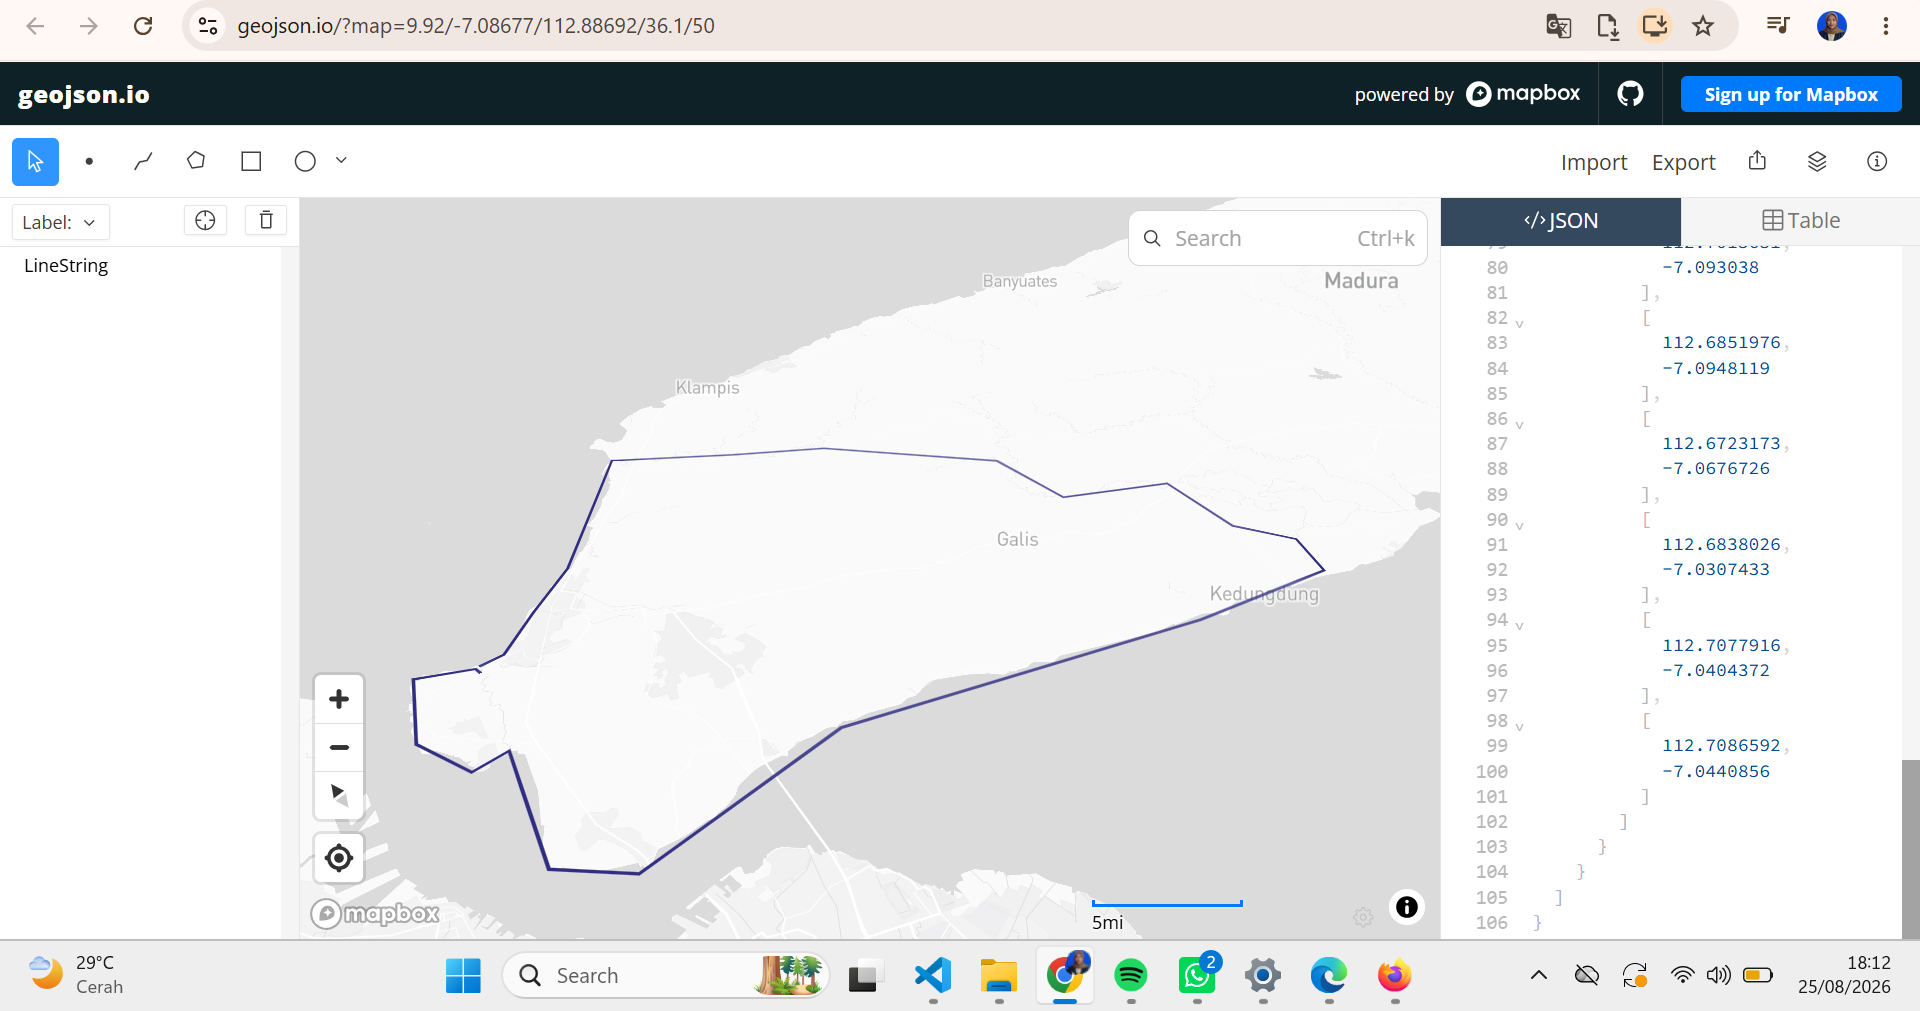

In [59]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.7096307, -7.0398682],
            [112.7211862, -7.0392129],
            [112.7429764, -7.0208632],
            [112.7690587, -7.0008743],
            [112.8273426, -6.9302456],
            [112.8835275, -6.9640896],
            [112.9276856, -6.9883133],
            [112.9971103, -7.0536224],
            [113.0031473, -7.0991547],
            [113.0563957, -7.1225576],
            [113.0553863, -7.1671046],
            [113.0724605, -7.1927095],
            [113.0632787, -7.2158838],
            [112.9879140, -7.2044249],
            [112.8172278, -7.1614931],
            [112.7170484, -7.1759788],
            [112.6913203, -7.1549554],
            [112.7015631, -7.0930380],
            [112.6851976, -7.0948119],
            [112.6723173, -7.0676726],
            [112.6838026, -7.0307433],
            [112.7077916, -7.0404372],
            [112.7086592, -7.0440856],
            [112.7096307, -7.0398682]
        ]
    ]
}

### B. Periode data

Pada tahap ini menentukan periode pengambilan data. Data dimulai pada 31 Agustus 2025 dan menggunakan 1 September 2026 sebagai batas akhir agar tanggal 31 Agustus 2026 dapat termasuk dalam rentang pengambilan data.


In [60]:
temporal_extent=["2025-08-31", "2026-09-01"] #disini sampai 2026-09-01 supaya berenti di 2026-09-01

In [61]:
!pip install openeo

In [62]:
import openeo

connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
)

connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

### C. CO

**Karbon Monoksida (CO)** merupakan salah satu polutan udara yang berkaitan dengan proses pembakaran tidak sempurna. CO dapat berasal dari aktivitas kendaraan bermotor, pembakaran bahan bakar, kegiatan industri, maupun pembakaran terbuka.

Pada tahap ini diambil data CO dari **Sentinel-5P** untuk wilayah Kabupaten Bangkalan selama periode 31 Agustus 2025–31 Agustus 2026.

Data kemudian dilakukan dua proses agregasi, yaitu:

1. **Agregasi temporal harian**, untuk mendapatkan nilai rata-rata CO setiap hari.
2. **Agregasi spasial**, untuk mendapatkan nilai rata-rata CO pada wilayah AOI Kabupaten Bangkalan.

Hasil pengambilan data kemudian disimpan dalam file **CO.nc** untuk tahap pengolahan selanjutnya.


In [63]:
!pip install netCDF4

import netCDF4
import pandas as pd
import numpy as np

In [64]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["CO"],
)

# Agregasi harian
s5p_co_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

# Simpan hasil data
job = s5p_co_aoi.execute_batch(
    title="CO",
    outputfile="CO.nc"
)

# Menjalankan proses sampai selesai
job.start_and_wait()

# =====================================================
# CEK DATA YANG BERHASIL DISIMPAN
# =====================================================

import netCDF4

ds = netCDF4.Dataset("CO.nc")

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu NetCDF menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("DATA CO BERHASIL DISIMPAN")
print("Tanggal awal  :", dates[0])
print("Tanggal akhir :", dates[-1])
print("Jumlah data   :", len(dates))

ds.close()

0:00:00 Job 'j-26090504540745819da7bbd0505fe764': send 'start'
0:00:03 Job 'j-26090504540745819da7bbd0505fe764': created (progress 0%)
0:00:08 Job 'j-26090504540745819da7bbd0505fe764': queued (progress 0%)
0:00:14 Job 'j-26090504540745819da7bbd0505fe764': queued (progress 0%)
0:00:23 Job 'j-26090504540745819da7bbd0505fe764': queued (progress 0%)
0:00:33 Job 'j-26090504540745819da7bbd0505fe764': queued (progress 0%)
0:00:45 Job 'j-26090504540745819da7bbd0505fe764': queued (progress 0%)
0:01:01 Job 'j-26090504540745819da7bbd0505fe764': queued (progress 0%)
0:01:20 Job 'j-26090504540745819da7bbd0505fe764': running (progress N/A)
0:01:44 Job 'j-26090504540745819da7bbd0505fe764': running (progress N/A)
0:02:14 Job 'j-26090504540745819da7bbd0505fe764': running (progress N/A)
0:02:52 Job 'j-26090504540745819da7bbd0505fe764': running (progress N/A)
0:03:39 Job 'j-26090504540745819da7bbd0505fe764': finished (progress 100%)
0:00:00 Job 'j-26090504540745819da7bbd0505fe764': send 'start'
0:00:01 J

### D. NO₂

**Nitrogen Dioksida (NO₂)** merupakan salah satu polutan udara yang banyak berkaitan dengan aktivitas pembakaran bahan bakar. Sumber NO₂ dapat berasal dari kendaraan bermotor, kegiatan industri, pembangkit listrik, dan proses pembakaran lainnya.

Data NO₂ diambil dari Sentinel-5P dengan batas wilayah Kabupaten Bangkalan dan periode pengamatan satu tahun.

Data kemudian diagregasi secara harian dan spasial sehingga diperoleh nilai rata-rata NO₂ pada wilayah penelitian untuk setiap waktu pengamatan. Hasilnya disimpan dalam file **NO2.nc**.


In [65]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["NO2"],
)

# Agregasi harian
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="NO2",
    outputfile="NO2.nc"
)

import netCDF4

# Buka file hasil crawling
ds = netCDF4.Dataset("NO2.nc")

# Cek variabel yang tersedia
print("Variabel dalam file:")
print(list(ds.variables.keys()))

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu NetCDF menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

# Hasil pengecekan
print("HASIL PENGECEKAN DATA NO2")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-2609050457544fcdb4f40c97c11409e3': send 'start'
0:00:03 Job 'j-2609050457544fcdb4f40c97c11409e3': queued (progress 0%)
0:00:09 Job 'j-2609050457544fcdb4f40c97c11409e3': queued (progress 0%)
0:00:15 Job 'j-2609050457544fcdb4f40c97c11409e3': queued (progress 0%)
0:00:23 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:00:33 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:00:46 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:01:01 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:01:21 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:01:45 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:02:15 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:02:52 Job 'j-2609050457544fcdb4f40c97c11409e3': running (progress N/A)
0:03:39 Job 'j-2609050457544fcdb4f40c97c11409e3': finished (progress 100%)
Variabel dalam file:
['t', 'x', 'y', 'crs', 'NO2']
HASIL PENGECEK

### E. HCHO

**HCHO (Formaldehida)** merupakan senyawa yang dapat ditemukan di atmosfer dan dapat berasal dari berbagai proses pembakaran maupun aktivitas manusia.

Pada tahap ini dilakukan pengambilan data HCHO dari Sentinel-5P pada wilayah Kabupaten Bangkalan. Data dibatasi berdasarkan AOI dan periode 31 Agustus 2025 sampai 31 Agustus 2026.

Data kemudian diagregasi secara temporal menjadi data harian dan secara spasial berdasarkan wilayah penelitian. Hasil pengambilan data disimpan dalam file **HCHO.nc**.


In [66]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["HCHO"],
)

# Agregasi harian
s5p_hcho_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_hcho_aoi = s5p_hcho_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="HCHO",
    outputfile="HCHO.nc"
)


import netCDF4

ds = netCDF4.Dataset("HCHO.nc")

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA HCHO")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-2609050501404c7694b1d3cf707d1f25': send 'start'
0:00:03 Job 'j-2609050501404c7694b1d3cf707d1f25': created (progress 0%)
0:00:08 Job 'j-2609050501404c7694b1d3cf707d1f25': queued (progress 0%)
0:00:15 Job 'j-2609050501404c7694b1d3cf707d1f25': queued (progress 0%)
0:00:23 Job 'j-2609050501404c7694b1d3cf707d1f25': queued (progress 0%)
0:00:33 Job 'j-2609050501404c7694b1d3cf707d1f25': running (progress N/A)
0:00:46 Job 'j-2609050501404c7694b1d3cf707d1f25': running (progress N/A)
0:01:01 Job 'j-2609050501404c7694b1d3cf707d1f25': running (progress N/A)
0:01:20 Job 'j-2609050501404c7694b1d3cf707d1f25': running (progress N/A)
0:01:44 Job 'j-2609050501404c7694b1d3cf707d1f25': running (progress N/A)
0:02:14 Job 'j-2609050501404c7694b1d3cf707d1f25': running (progress N/A)
0:02:52 Job 'j-2609050501404c7694b1d3cf707d1f25': running (progress N/A)
0:03:39 Job 'j-2609050501404c7694b1d3cf707d1f25': finished (progress 100%)
HASIL PENGECEKAN DATA HCHO
Tanggal pertama : 2025-08-31 00:00:00
T

### F. O₃

**Ozon (O₃)** merupakan polutan sekunder yang terbentuk melalui reaksi kimia di atmosfer dengan bantuan sinar matahari. Pembentukan O₃ berkaitan dengan keberadaan prekursor seperti nitrogen oksida (NOx) dan senyawa organik volatil (VOC).

Data O₃ diperoleh dari Sentinel-5P untuk wilayah Kabupaten Bangkalan selama periode penelitian.

Sama seperti polutan lainnya, data O₃ diagregasi berdasarkan waktu dan wilayah sehingga dapat digunakan untuk melihat perubahan konsentrasi O₃ dari hari ke hari. Data hasil pengambilan disimpan dalam file **O3.nc**.


In [67]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["O3"],
)

# Agregasi harian
s5p_o3_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_o3_aoi = s5post.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="O3",
    outputfile="O3.nc"
)


import netCDF4

ds = netCDF4.Dataset("O3.nc")

# Ambil variabel waktu
time_var = ds.variables["t"]

# Konversi waktu menjadi tanggal
dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA O3")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-260905050526420a9493b874f634c064': send 'start'
0:00:03 Job 'j-260905050526420a9493b874f634c064': created (progress 0%)
0:00:08 Job 'j-260905050526420a9493b874f634c064': queued (progress 0%)
0:00:14 Job 'j-260905050526420a9493b874f634c064': queued (progress 0%)
0:00:23 Job 'j-260905050526420a9493b874f634c064': queued (progress 0%)
0:00:33 Job 'j-260905050526420a9493b874f634c064': queued (progress 0%)
0:00:45 Job 'j-260905050526420a9493b874f634c064': queued (progress 0%)
0:01:01 Job 'j-260905050526420a9493b874f634c064': running (progress N/A)
0:01:20 Job 'j-260905050526420a9493b874f634c064': running (progress N/A)
0:01:45 Job 'j-260905050526420a9493b874f634c064': running (progress N/A)
0:02:15 Job 'j-260905050526420a9493b874f634c064': running (progress N/A)
0:02:53 Job 'j-260905050526420a9493b874f634c064': finished (progress 100%)
HASIL PENGECEKAN DATA O3
Tanggal pertama : 2025-08-31 00:00:00
Tanggal terakhir: 2026-08-31 00:00:00
Jumlah data     : 362


### G. SO₂

**Sulfur Dioksida (SO₂)** merupakan gas pencemar yang terutama berkaitan dengan pembakaran bahan bakar yang mengandung sulfur. Sumber SO₂ dapat berasal dari kegiatan industri, pembangkit listrik, dan pembakaran bahan bakar fosil.

Data SO₂ diambil dari Sentinel-5P pada wilayah Kabupaten Bangkalan dengan periode pengamatan satu tahun.

Data kemudian diagregasi secara harian dan berdasarkan wilayah AOI. Hasil pengambilan data disimpan dalam file **SO2.nc**.


In [68]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["SO2"],
)

# Agregasi harian
s5p_so2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_so2_aoi = s5post.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="SO2",
    outputfile="SO2.nc"
)

import netCDF4

ds = netCDF4.Dataset("SO2.nc")

time_var = ds.variables["t"]

dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA SO2")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-2609050508254171b47bcf0253887dbf': send 'start'
0:00:03 Job 'j-2609050508254171b47bcf0253887dbf': queued (progress 0%)
0:00:08 Job 'j-2609050508254171b47bcf0253887dbf': queued (progress 0%)
0:00:15 Job 'j-2609050508254171b47bcf0253887dbf': queued (progress 0%)
0:00:23 Job 'j-2609050508254171b47bcf0253887dbf': queued (progress 0%)
0:00:33 Job 'j-2609050508254171b47bcf0253887dbf': queued (progress 0%)
0:00:45 Job 'j-2609050508254171b47bcf0253887dbf': queued (progress 0%)
0:01:01 Job 'j-2609050508254171b47bcf0253887dbf': running (progress N/A)
0:01:20 Job 'j-2609050508254171b47bcf0253887dbf': running (progress N/A)
0:01:44 Job 'j-2609050508254171b47bcf0253887dbf': running (progress N/A)
0:02:14 Job 'j-2609050508254171b47bcf0253887dbf': running (progress N/A)
0:02:52 Job 'j-2609050508254171b47bcf0253887dbf': running (progress N/A)
0:03:39 Job 'j-2609050508254171b47bcf0253887dbf': finished (progress 100%)
HASIL PENGECEKAN DATA SO2
Tanggal pertama : 2025-08-31 00:00:00
Tanggal

### H. CH₄

**Metana (CH₄)** merupakan gas rumah kaca yang dapat berasal dari aktivitas manusia maupun proses alami. Beberapa sumber CH₄ antara lain aktivitas pertanian dan peternakan, tempat pembuangan sampah, serta produksi dan penggunaan bahan bakar fosil.

Data CH₄ diambil dari Sentinel-5P pada wilayah Kabupaten Bangkalan selama periode 31 Agustus 2025 sampai 31 Agustus 2026.

Data kemudian diagregasi secara temporal dan spasial untuk memperoleh data yang dapat digunakan dalam analisis time series. Hasil pengambilan disimpan dalam file **CH4.nc**.


In [69]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent={
        "west": 112.6723173,
        "south": -7.2158838,
        "east": 113.0724605,
        "north": -6.9302456
    },
    bands=["CH4"],
)

# Agregasi harian
s5p_ch4_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial pada AOI
s5p_ch4_aoi = s5post.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5post.execute_batch(
    title="CH4",
    outputfile="CH4.nc"
)

import netCDF4

ds = netCDF4.Dataset("CH4.nc")

time_var = ds.variables["t"]

dates = netCDF4.num2date(
    time_var[:],
    units=time_var.units,
    calendar=getattr(time_var, "calendar", "standard")
)

print("HASIL PENGECEKAN DATA CH4")
print("Tanggal pertama :", dates[0])
print("Tanggal terakhir:", dates[-1])
print("Jumlah data     :", len(dates))

ds.close()

0:00:00 Job 'j-26090505121049e19a4769a3156ef893': send 'start'
0:00:02 Job 'j-26090505121049e19a4769a3156ef893': queued (progress 0%)
0:00:08 Job 'j-26090505121049e19a4769a3156ef893': queued (progress 0%)
0:00:14 Job 'j-26090505121049e19a4769a3156ef893': queued (progress 0%)
0:00:22 Job 'j-26090505121049e19a4769a3156ef893': queued (progress 0%)
0:00:32 Job 'j-26090505121049e19a4769a3156ef893': queued (progress 0%)
0:00:45 Job 'j-26090505121049e19a4769a3156ef893': queued (progress 0%)
0:01:00 Job 'j-26090505121049e19a4769a3156ef893': running (progress N/A)
0:01:20 Job 'j-26090505121049e19a4769a3156ef893': running (progress N/A)
0:01:44 Job 'j-26090505121049e19a4769a3156ef893': running (progress N/A)
0:02:14 Job 'j-26090505121049e19a4769a3156ef893': running (progress N/A)
0:02:52 Job 'j-26090505121049e19a4769a3156ef893': running (progress N/A)
0:03:38 Job 'j-26090505121049e19a4769a3156ef893': finished (progress 100%)
HASIL PENGECEKAN DATA CH4
Tanggal pertama : 2025-08-31 00:00:00
Tanggal

## 2. Mengubah Data NetCDF Menjadi CSV

Data hasil pengambilan dari Sentinel-5P masih disimpan dalam format **NetCDF (.nc)**. Format tersebut digunakan untuk menyimpan data ilmiah yang memiliki dimensi waktu dan spasial.

Pada tahap ini dibuat fungsi untuk mengubah data NetCDF menjadi **CSV** agar lebih mudah diperiksa, dianalisis, dan digunakan untuk membuat grafik.

Proses yang dilakukan meliputi:

1. membaca file NetCDF;
2. mengambil variabel polutan;
3. mengambil informasi waktu;
4. mengubah waktu menjadi format tanggal;
5. menangani nilai kosong atau masked value;
6. menghitung rata-rata nilai grid spasial untuk setiap tanggal; dan
7. menyimpan hasilnya dalam bentuk data time series.


In [70]:
import netCDF4
import pandas as pd
import numpy as np

def netcdf_to_csv(file_path, variable_name, output_csv):

    ds = netCDF4.Dataset(file_path)

    # Ambil waktu
    time_var = ds.variables["t"]

    dates = netCDF4.num2date(
        time_var[:],
        units=time_var.units,
        calendar=getattr(time_var, "calendar", "standard")
    )

    # Ubah tanggal menjadi format pandas
    dates = pd.to_datetime([
        d.strftime("%Y-%m-%d")
        for d in dates
    ])

    # Ambil data polutan
    data = ds.variables[variable_name][:]

    # Ubah masked array menjadi array biasa
    data = np.ma.filled(data, np.nan)

    # Tampilkan bentuk data untuk pengecekan
    print(f"\n{variable_name}")
    print("Jumlah tanggal :", len(dates))
    print("Bentuk data    :", data.shape)

    # Karena data sudah diagregasi spasial,
    # ambil nilai berdasarkan dimensi waktu
    data = np.asarray(data)

    if data.ndim > 1:
        data = data.reshape(data.shape[0], -1)
        data = np.nanmean(data, axis=1)

    # Pastikan jumlah data sama dengan jumlah tanggal
    jumlah = min(len(dates), len(data))

    dates = dates[:jumlah]
    data = data[:jumlah]

    # Buat DataFrame
    df = pd.DataFrame({
        "date": dates,
        variable_name: data
    })

    # Simpan CSV
    df.to_csv(output_csv, index=False)

    print("Tanggal awal  :", df["date"].min())
    print("Tanggal akhir :", df["date"].max())
    print("Jumlah data   :", len(df))
    print("Berhasil disimpan:", output_csv)

    ds.close()

    return df

## 3. Memproses semua polutan

Pembuatan CSV Masing-Masing Polutan

Fungsi yang telah dibuat kemudian diterapkan pada seluruh data polutan, yaitu CO, NO₂, HCHO, O₃, SO₂, dan CH₄.

Setiap file NetCDF diubah menjadi file CSV time series. Dengan demikian, setiap polutan memiliki data tanggal dan nilai konsentrasi yang dapat digunakan untuk tahap eksplorasi dan visualisasi.


In [71]:
df_co = netcdf_to_csv(
    "CO.nc",
    "CO",
    "CO_timeseries.csv"
)

df_no2 = netcdf_to_csv(
    "NO2.nc",
    "NO2",
    "NO2_timeseries.csv"
)

df_hcho = netcdf_to_csv(
    "HCHO.nc",
    "HCHO",
    "HCHO_timeseries.csv"
)

df_o3 = netcdf_to_csv(
    "O3.nc",
    "O3",
    "O3_timeseries.csv"
)

df_so2 = netcdf_to_csv(
    "SO2.nc",
    "SO2",
    "SO2_timeseries.csv"
)

df_ch4 = netcdf_to_csv(
    "CH4.nc",
    "CH4",
    "CH4_timeseries.csv"
)


CO
Jumlah tanggal : 264
Bentuk data    : (1, 264)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2025-08-31 00:00:00
Jumlah data   : 1
Berhasil disimpan: CO_timeseries.csv

NO2
Jumlah tanggal : 364
Bentuk data    : (364, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-31 00:00:00
Jumlah data   : 364
Berhasil disimpan: NO2_timeseries.csv

HCHO
Jumlah tanggal : 352
Bentuk data    : (352, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-31 00:00:00
Jumlah data   : 352
Berhasil disimpan: HCHO_timeseries.csv

O3
Jumlah tanggal : 362
Bentuk data    : (362, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-31 00:00:00
Jumlah data   : 362
Berhasil disimpan: O3_timeseries.csv

SO2
Jumlah tanggal : 352
Bentuk data    : (352, 9, 8)
Tanggal awal  : 2025-08-31 00:00:00
Tanggal akhir : 2026-08-31 00:00:00
Jumlah data   : 352
Berhasil disimpan: SO2_timeseries.csv

CH4
Jumlah tanggal : 216
Bentuk data    : (216, 9, 8)
Tanggal awal  : 2025-08-31 

/tmp/ipykernel_1562/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)
/tmp/ipykernel_1562/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)
/tmp/ipykernel_1562/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)
/tmp/ipykernel_1562/1857651657.py:41: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=1)


## 4. Cek semua CSV

 Pemeriksaan Data CSV

Setelah proses konversi selesai, dilakukan pemeriksaan terhadap seluruh file CSV.

Pemeriksaan ini bertujuan untuk memastikan bahwa file berhasil dibuat dan mengetahui:

* contoh data yang diperoleh;
* jumlah baris atau jumlah pengamatan;
* jumlah kolom;
* struktur data yang digunakan; dan
* apakah data sudah memiliki periode pengamatan yang sesuai.

Tahap ini merupakan pemeriksaan awal sebelum masuk ke proses **Data Understanding**.


In [72]:
files = [
    "CO_timeseries.csv",
    "NO2_timeseries.csv",
    "HCHO_timeseries.csv",
    "O3_timeseries.csv",
    "SO2_timeseries.csv",
    "CH4_timeseries.csv"
]

for file in files:
    print("\n" + "=" * 60)
    print(file)
    print("=" * 60)

    data = pd.read_csv(file)

    print(data.head())
    print("\nJumlah baris:", len(data))
    print("Jumlah kolom:", len(data.columns))


CO_timeseries.csv
         date        CO
0  2025-08-31  0.028662

Jumlah baris: 1
Jumlah kolom: 2

NO2_timeseries.csv
         date       NO2
0  2025-08-31  0.000014
1  2025-09-01  0.000016
2  2025-09-02  0.000014
3  2025-09-03  0.000014
4  2025-09-04  0.000018

Jumlah baris: 364
Jumlah kolom: 2

HCHO_timeseries.csv
         date      HCHO
0  2025-08-31  0.000129
1  2025-09-01  0.000069
2  2025-09-02  0.000055
3  2025-09-03  0.000083
4  2025-09-04  0.000079

Jumlah baris: 352
Jumlah kolom: 2

O3_timeseries.csv
         date        O3
0  2025-08-31  0.115841
1  2025-09-01  0.115376
2  2025-09-02  0.113657
3  2025-09-03  0.113616
4  2025-09-04  0.113226

Jumlah baris: 362
Jumlah kolom: 2

SO2_timeseries.csv
         date       SO2
0  2025-08-31  0.000021
1  2025-09-01  0.000029
2  2025-09-02 -0.000038
3  2025-09-03  0.000034
4  2025-09-04  0.000042

Jumlah baris: 352
Jumlah kolom: 2

CH4_timeseries.csv
         date        CH4
0  2025-08-31        NaN
1  2025-09-01        NaN
2  2025-0

In [73]:
# MENYATUKAN SEMUA CSV POLUTAN

# Membaca masing-masing CSV
co = pd.read_csv("CO_timeseries.csv")
no2 = pd.read_csv("NO2_timeseries.csv")
hcho = pd.read_csv("HCHO_timeseries.csv")
o3 = pd.read_csv("O3_timeseries.csv")
so2 = pd.read_csv("SO2_timeseries.csv")
ch4 = pd.read_csv("CH4_timeseries.csv")

# Mengubah kolom date menjadi datetime
co["date"] = pd.to_datetime(co["date"])
no2["date"] = pd.to_datetime(no2["date"])
hcho["date"] = pd.to_datetime(hcho["date"])
o3["date"] = pd.to_datetime(o3["date"])
so2["date"] = pd.to_datetime(so2["date"])
ch4["date"] = pd.to_datetime(ch4["date"])

# Menggabungkan semua CSV berdasarkan tanggal
data_gabungan = co.merge(no2, on="date", how="outer")
data_gabungan = data_gabungan.merge(hcho, on="date", how="outer")
data_gabungan = data_gabungan.merge(o3, on="date", how="outer")
data_gabungan = data_gabungan.merge(so2, on="date", how="outer")
data_gabungan = data_gabungan.merge(ch4, on="date", how="outer")

# Mengurutkan berdasarkan tanggal
data_gabungan = data_gabungan.sort_values("date")

# Menyimpan menjadi satu CSV
data_gabungan.to_csv(
    "Data_Polutan_Bangkalan_Gabungan.csv",
    index=False
)

# Menampilkan hasil
print("Data berhasil digabungkan!")
print("Jumlah baris:", len(data_gabungan))
print("Jumlah kolom:", len(data_gabungan.columns))

display(data_gabungan.head())

Data berhasil digabungkan!
Jumlah baris: 366
Jumlah kolom: 7


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.028662,0.000014,0.000129,0.115841,0.000021,NaN
1,2025-09-01,NaN,0.000016,0.000069,0.115376,0.000029,NaN
2,2025-09-02,NaN,0.000014,0.000055,0.113657,-0.000038,1837.7645
3,2025-09-03,NaN,0.000014,0.000083,0.113616,0.000034,1888.4973
4,2025-09-04,NaN,0.000018,0.000079,0.113226,0.000042,1832.4469


## 5. Data Understanding

Tahap Data Understanding dilakukan untuk memahami karakteristik data polutan yang telah diperoleh dari wilayah Kabupaten Bangkalan.

Eksplorasi dilakukan terhadap seluruh polutan dengan beberapa pemeriksaan, yaitu:

1. **Struktur data**, untuk mengetahui jumlah data, nama kolom, tipe data, dan contoh isi data.
2. **Statistik deskriptif**, untuk mengetahui nilai minimum, maksimum, rata-rata, median, dan penyebaran data.
3. **Missing value**, untuk mengetahui apakah terdapat data yang kosong.
4. **Outlier**, untuk mengetahui apakah terdapat nilai yang berbeda jauh dari sebagian besar pengamatan.
5. **Rentang waktu**, untuk memastikan data mencakup periode penelitian.
6. **Pola data**, yang selanjutnya akan diamati melalui grafik time series.

Eksplorasi ini dilakukan untuk mengetahui apakah terdapat data yang tidak lengkap atau data yang memiliki karakteristik tidak biasa sebelum dilakukan analisis lebih lanjut.


In [74]:
def data_understanding(
    file_path,
    variable_name
):

    print("\n")
    print("=" * 70)
    print(f"DATA UNDERSTANDING - {variable_name}")
    print("=" * 70)

    df = pd.read_csv(file_path)

    df["date"] = pd.to_datetime(df["date"])

    # -------------------------------------------------
    # 1. Struktur dan isi data
    # -------------------------------------------------

    print("\n1. Struktur Data")
    print("-" * 40)

    print(df.info())

    print("\n5 data pertama:")
    print(df.head())

    print("\n5 data terakhir:")
    print(df.tail())

    # -------------------------------------------------
    # 2. Statistik deskriptif
    # -------------------------------------------------

    print("\n2. Statistik Deskriptif")
    print("-" * 40)

    print(
        df[variable_name].describe()
    )

    # -------------------------------------------------
    # 3. Missing value
    # -------------------------------------------------

    print("\n3. Missing Value")
    print("-" * 40)

    print(
        "Jumlah missing:",
        df[variable_name].isna().sum()
    )

    print(
        "Persentase missing:",
        round(
            df[variable_name].isna().mean() * 100,
            2
        ),
        "%"
    )

    # -------------------------------------------------
    # 4. Missing tanggal
    # -------------------------------------------------

    print("\n4. Missing Date")
    print("-" * 40)

    full_range = pd.date_range(
        start="2025-08-31",
        end="2026-08-31",
        freq="D"
    )

    missing_dates = full_range.difference(
        df["date"]
    )

    print(
        "Jumlah tanggal missing:",
        len(missing_dates)
    )

    if len(missing_dates) > 0:
        print("Tanggal missing:")
        print(missing_dates)

    # -------------------------------------------------
    # 5. Outlier menggunakan IQR
    # -------------------------------------------------

    print("\n5. Outlier - Metode IQR")
    print("-" * 40)

    Q1 = df[variable_name].quantile(0.25)
    Q3 = df[variable_name].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[variable_name] < lower_bound) |
        (df[variable_name] > upper_bound)
    ]

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)

    print("Batas bawah:", lower_bound)
    print("Batas atas:", upper_bound)

    print(
        "Jumlah outlier:",
        len(outliers)
    )

    if len(outliers) > 0:
        print("\nData outlier:")
        print(
            outliers[
                ["date", variable_name]
            ]
        )

    return df, outliers, lower_bound, upper_bound

### 5.1 Data Understanding untuk CO

Pada tahap ini dilakukan eksplorasi terhadap data **CO Kabupaten Bangkalan**.

Analisis meliputi struktur data, statistik deskriptif, missing value, serta deteksi outlier menggunakan metode **IQR (Interquartile Range)**.

Hasil eksplorasi digunakan untuk mengetahui karakteristik nilai CO selama periode pengamatan dan mengetahui apakah terdapat nilai yang tidak biasa.


In [75]:
co_df, co_outliers, co_lower, co_upper = data_understanding(
    "CO_timeseries.csv",
    "CO"
)



DATA UNDERSTANDING - CO

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1 non-null      datetime64[ns]
 1   CO      1 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 148.0 bytes
None

5 data pertama:
        date        CO
0 2025-08-31  0.028662

5 data terakhir:
        date        CO
0 2025-08-31  0.028662

2. Statistik Deskriptif
----------------------------------------
count    1.000000
mean     0.028662
std           NaN
min      0.028662
25%      0.028662
50%      0.028662
75%      0.028662
max      0.028662
Name: CO, dtype: float64

3. Missing Value
----------------------------------------
Jumlah missing: 0
Persentase missing: 0.0 %

4. Missing Date
----------------------------------------
Jumlah tanggal missing: 365
Tanggal missing:
Da

### 5.2 Data Understanding NO₂

Data NO₂ Kabupaten Bangkalan dianalisis untuk mengetahui struktur, statistik deskriptif, kelengkapan data, dan kemungkinan adanya outlier.

Hasil pemeriksaan digunakan untuk memahami karakteristik perubahan nilai NO₂ selama periode satu tahun.


In [76]:
no2_df, no2_outliers, no2_lower, no2_upper = data_understanding(
    "NO2_timeseries.csv",
    "NO2"
)



DATA UNDERSTANDING - NO2

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    364 non-null    datetime64[ns]
 1   NO2     284 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None

5 data pertama:
        date       NO2
0 2025-08-31  0.000014
1 2025-09-01  0.000016
2 2025-09-02  0.000014
3 2025-09-03  0.000014
4 2025-09-04  0.000018

5 data terakhir:
          date       NO2
359 2026-08-27  0.000029
360 2026-08-28  0.000031
361 2026-08-29  0.000022
362 2026-08-30  0.000017
363 2026-08-31  0.000022

2. Statistik Deskriptif
----------------------------------------
count    284.000000
mean       0.000027
std        0.000012
min        0.000005
25%        0.000020
50%        0.000026
75%        0.000032
max        0.000109
Name: NO2, dtype: flo

### 5.3 Data Understanding HCHO

Eksplorasi dilakukan terhadap data HCHO Kabupaten Bangkalan untuk mengetahui karakteristik data, statistik deskriptif, missing value, serta nilai yang terindikasi sebagai outlier.


In [77]:
hcho_df, hcho_outliers, hcho_lower, hcho_upper = data_understanding(
    "HCHO_timeseries.csv",
    "HCHO"
)



DATA UNDERSTANDING - HCHO

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    352 non-null    datetime64[ns]
 1   HCHO    317 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.6 KB
None

5 data pertama:
        date      HCHO
0 2025-08-31  0.000129
1 2025-09-01  0.000069
2 2025-09-02  0.000055
3 2025-09-03  0.000083
4 2025-09-04  0.000079

5 data terakhir:
          date      HCHO
347 2026-08-27  0.000164
348 2026-08-28  0.000153
349 2026-08-29  0.000108
350 2026-08-30  0.000044
351 2026-08-31  0.000116

2. Statistik Deskriptif
----------------------------------------
count    317.000000
mean       0.000167
std        0.000085
min       -0.000236
25%        0.000122
50%        0.000153
75%        0.000197
max        0.000593
Name: HCHO, dtype: f

### 5.4 Data Understanding O₃

Eksplorasi data O₃ dilakukan untuk mengetahui karakteristik nilai O₃ selama periode penelitian, termasuk statistik deskriptif, kelengkapan data, dan kemungkinan adanya nilai yang tidak biasa.


In [78]:
o3_df, o3_outliers, o3_lower, o3_upper = data_understanding(
    "O3_timeseries.csv",
    "O3"
)



DATA UNDERSTANDING - O3

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    362 non-null    datetime64[ns]
 1   O3      362 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None

5 data pertama:
        date        O3
0 2025-08-31  0.115841
1 2025-09-01  0.115376
2 2025-09-02  0.113657
3 2025-09-03  0.113616
4 2025-09-04  0.113226

5 data terakhir:
          date        O3
357 2026-08-27  0.117676
358 2026-08-28  0.117195
359 2026-08-29  0.115979
360 2026-08-30  0.114675
361 2026-08-31  0.116246

2. Statistik Deskriptif
----------------------------------------
count    362.000000
mean       0.115848
std        0.002272
min        0.110438
25%        0.114150
50%        0.115825
75%        0.117276
max        0.122721
Name: O3, dtype: float

### 5.5 Data Understanding SO₂

Data SO₂ Kabupaten Bangkalan diperiksa untuk mengetahui struktur data, statistik deskriptif, missing value, serta kemungkinan adanya outlier selama periode pengamatan.


In [79]:
so2_df, so2_outliers, so2_lower, so2_upper = data_understanding(
    "SO2_timeseries.csv",
    "SO2"
)



DATA UNDERSTANDING - SO2

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    352 non-null    datetime64[ns]
 1   SO2     308 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.6 KB
None

5 data pertama:
        date       SO2
0 2025-08-31  0.000021
1 2025-09-01  0.000029
2 2025-09-02 -0.000038
3 2025-09-03  0.000034
4 2025-09-04  0.000042

5 data terakhir:
          date       SO2
347 2026-08-27  0.000048
348 2026-08-28 -0.000048
349 2026-08-29  0.000102
350 2026-08-30 -0.000033
351 2026-08-31  0.000051

2. Statistik Deskriptif
----------------------------------------
count    308.000000
mean       0.000049
std        0.000140
min       -0.000966
25%       -0.000013
50%        0.000036
75%        0.000107
max        0.000619
Name: SO2, dtype: flo

### 5.6. Data Understanding CH₄

Data CH₄ Kabupaten Bangkalan dieksplorasi untuk mengetahui karakteristik data, statistik deskriptif, kelengkapan data, dan kemungkinan adanya nilai yang tidak biasa selama periode penelitian.


In [80]:
ch4_df, ch4_outliers, ch4_lower, ch4_upper = data_understanding(
    "CH4_timeseries.csv",
    "CH4"
)



DATA UNDERSTANDING - CH4

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    216 non-null    datetime64[ns]
 1   CH4     84 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB
None

5 data pertama:
        date        CH4
0 2025-08-31        NaN
1 2025-09-01        NaN
2 2025-09-02  1837.7645
3 2025-09-03  1888.4973
4 2025-09-04  1832.4469

5 data terakhir:
          date        CH4
211 2026-08-27  1892.7664
212 2026-08-28  1854.1284
213 2026-08-29        NaN
214 2026-08-30  1910.1371
215 2026-08-31  1897.7373

2. Statistik Deskriptif
----------------------------------------
count      84.000000
mean     1867.266076
std        43.570326
min      1632.623400
25%      1851.683675
50%      1881.922300
75%      1895.277775
max      1931.454600
N

## 6. Grafik Time Series

Tahap berikutnya adalah memvisualisasikan data dalam bentuk **grafik time series**.

Grafik time series digunakan untuk melihat perubahan nilai masing-masing polutan berdasarkan tanggal selama periode 31 Agustus 2025 sampai 31 Agustus 2026.

Melalui grafik ini dapat diamati pola perubahan konsentrasi polutan, seperti kecenderungan meningkat, menurun, relatif stabil, atau mengalami lonjakan pada waktu tertentu.




In [81]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_time_series(df, variable_name):

    df = df.copy()

    # Pastikan tanggal dalam format datetime
    df["date"] = pd.to_datetime(df["date"])

    # Hapus data yang kosong
    df = df.dropna(subset=["date", variable_name])

    print("Jumlah data yang diplot:", len(df))
    print("Tanggal awal:", df["date"].min())
    print("Tanggal akhir:", df["date"].max())

    plt.figure(figsize=(15, 5))

    plt.plot(
        df["date"],
        df[variable_name],
        linewidth=1
    )

    plt.title(f"Time Series Kadar {variable_name}")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {variable_name}")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### 6.1 Grafik CO

Time Series CO Kabupaten Bangkalan

Grafik berikut menunjukkan perubahan nilai CO dari waktu ke waktu selama periode pengamatan. Grafik digunakan untuk melihat pola dan fluktuasi CO di wilayah Kabupaten Bangkalan.


Jumlah data yang diplot: 1
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2025-08-31 00:00:00


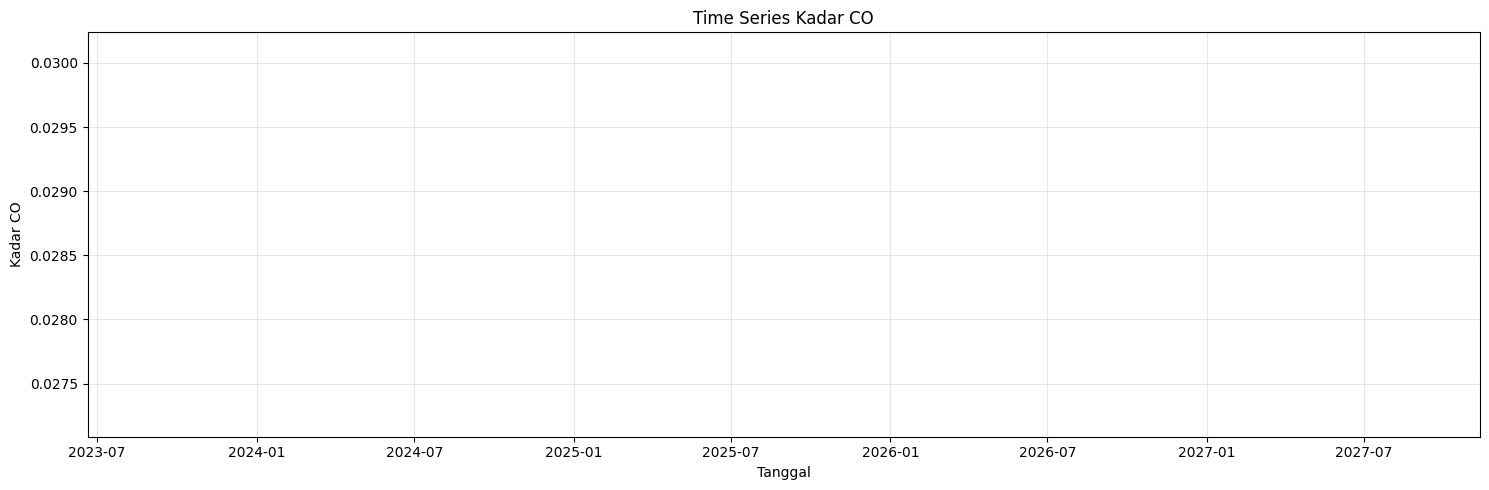

In [82]:
plot_time_series(
    df_co,
    "CO"
)

### 6.2 Grafik NO₂

Time Series NO₂ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai NO₂ harian selama periode penelitian. Pola naik dan turun pada grafik dapat digunakan untuk melihat perubahan konsentrasi NO₂ dari waktu ke waktu.


Jumlah data yang diplot: 284
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-31 00:00:00


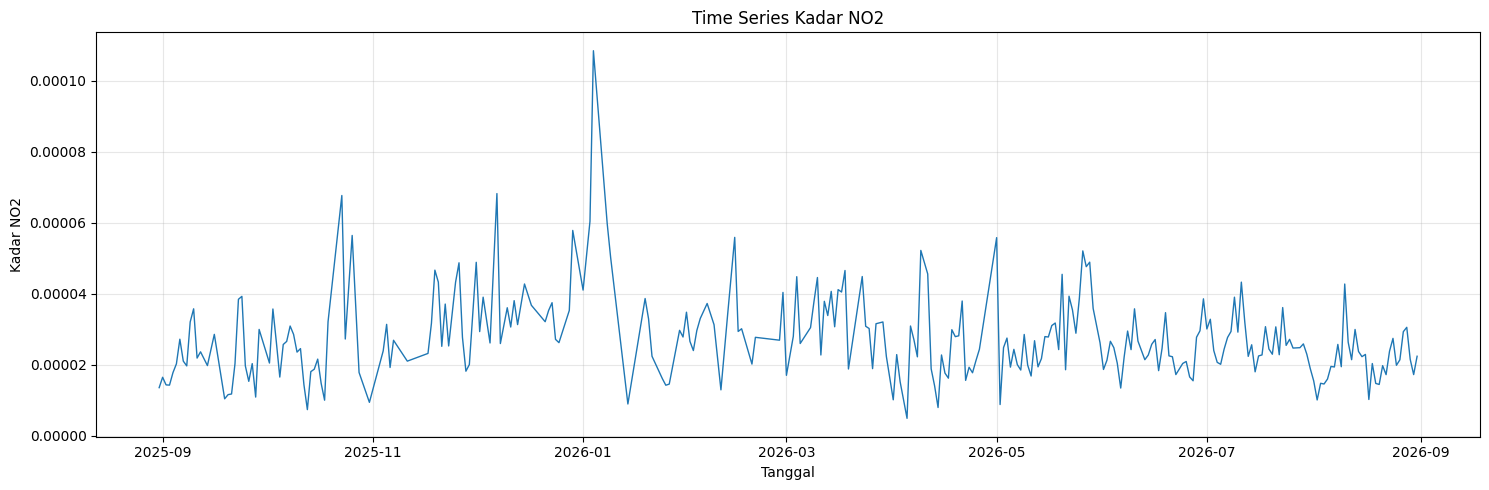

In [83]:
plot_time_series(
    no2_df,
    "NO2"
)

### 6.3 Grafik HCHO
Time Series HCHO Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai HCHO selama periode pengamatan dan digunakan untuk melihat pola fluktuasi HCHO berdasarkan waktu.


Jumlah data yang diplot: 317
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-31 00:00:00


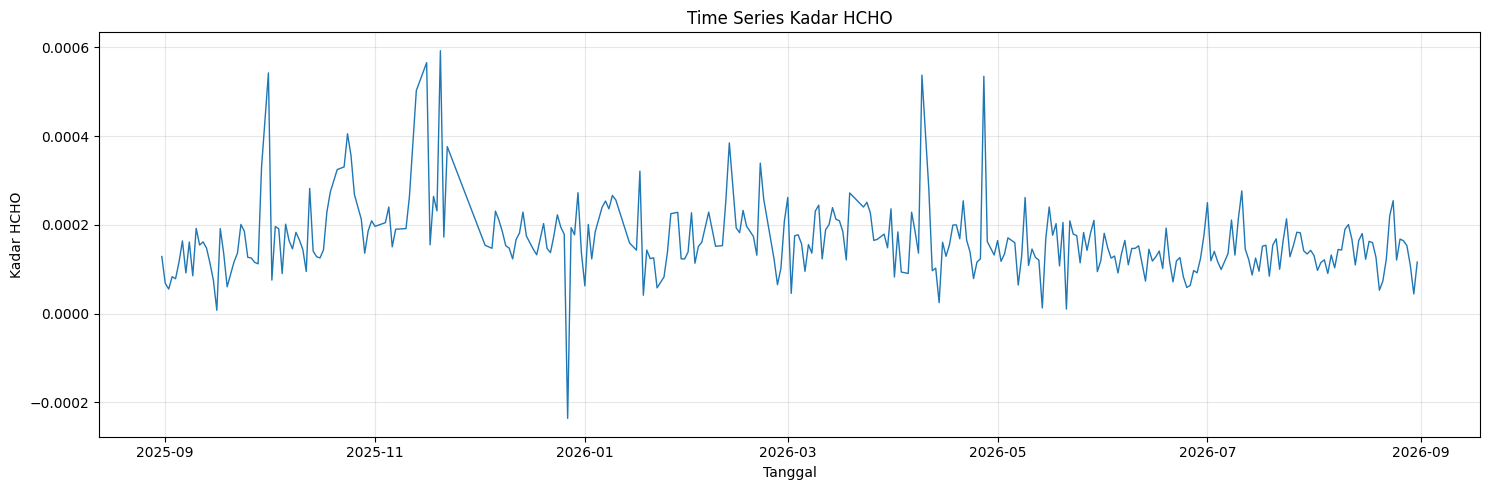

In [84]:
plot_time_series(
    hcho_df,
    "HCHO"
)

### 6.4 Grafik O₃

Time Series O₃ Kabupaten Bangkalan

Grafik digunakan untuk melihat perubahan nilai O₃ dari waktu ke waktu selama periode penelitian dan mengidentifikasi pola fluktuasinya.


Jumlah data yang diplot: 362
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-31 00:00:00


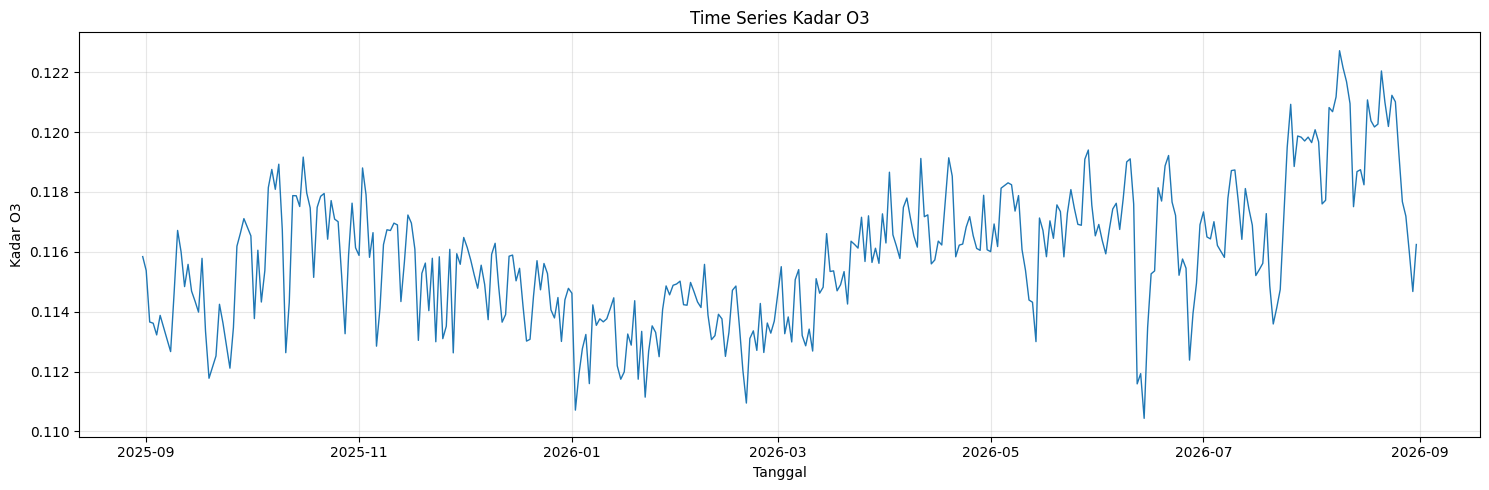

In [85]:
plot_time_series(
    o3_df,
    "O3"
)

### 6.5 Grafik SO₂

Time Series SO₂ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai SO₂ selama periode pengamatan sehingga dapat diamati pola naik-turun nilai SO₂ dari waktu ke waktu.


Jumlah data yang diplot: 308
Tanggal awal: 2025-08-31 00:00:00
Tanggal akhir: 2026-08-31 00:00:00


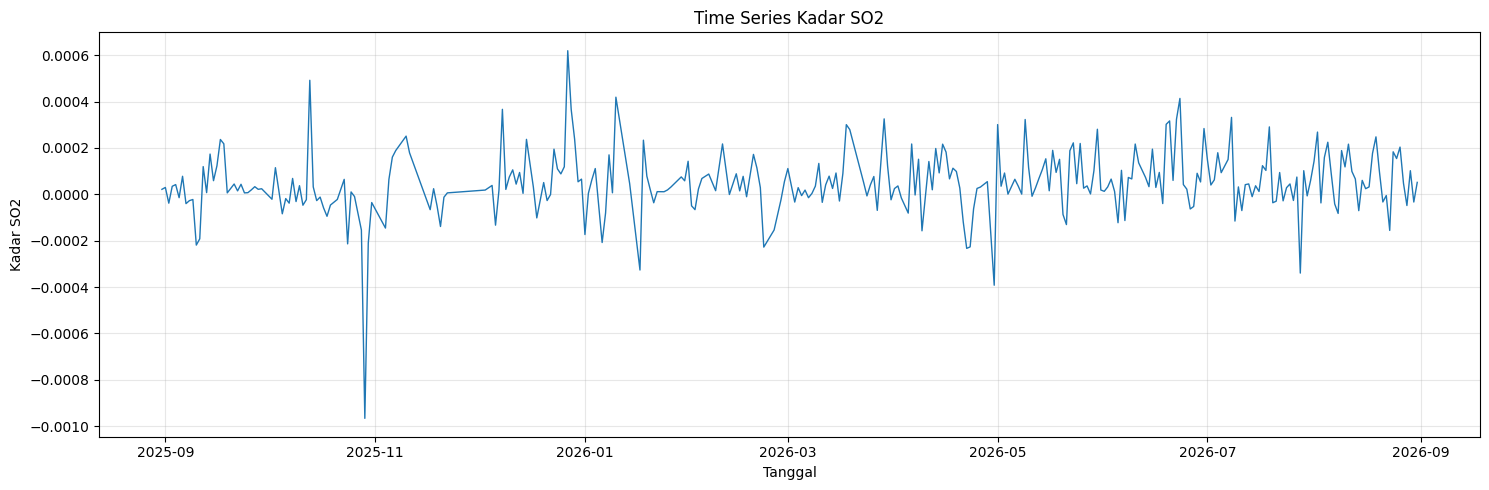

In [86]:
plot_time_series(
    so2_df,
    "SO2"
)

### 6.6 Grafik CH₄

Time Series CH₄ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai CH₄ selama periode penelitian dan digunakan untuk mengamati pola serta fluktuasi nilai CH₄ berdasarkan waktu.


Jumlah data yang diplot: 84
Tanggal awal: 2025-09-02 00:00:00
Tanggal akhir: 2026-08-31 00:00:00


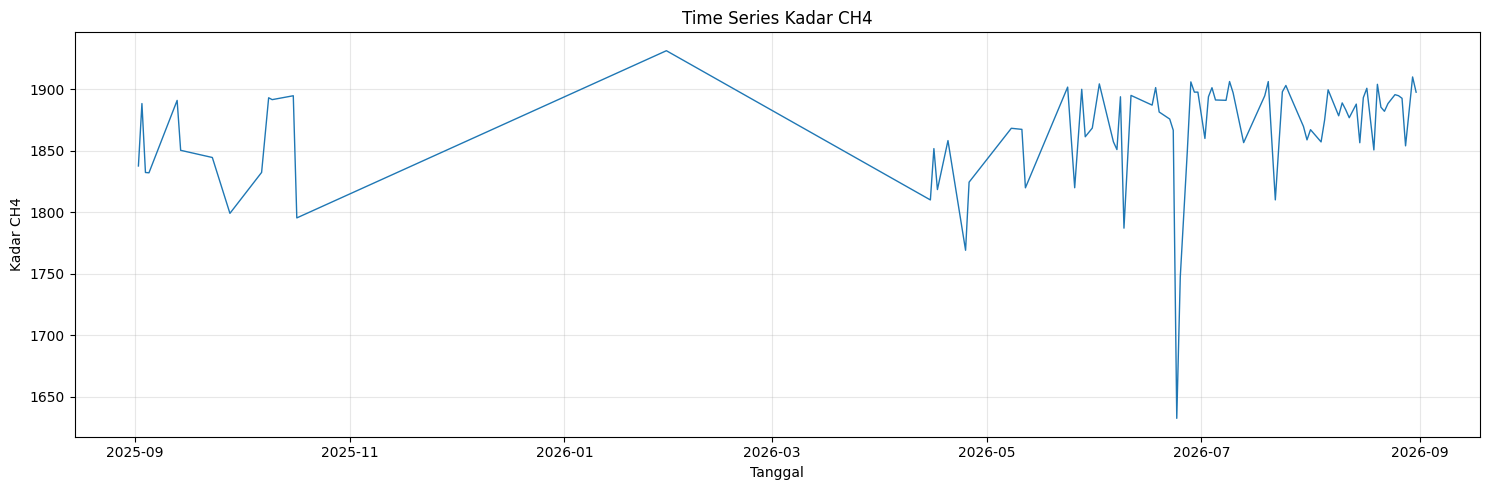

In [87]:
plot_time_series(
    ch4_df,
    "CH4"
)

### 7. Grafik outlier


Deteksi outlier dilakukan untuk mengetahui apakah terdapat nilai polutan yang memiliki perbedaan cukup jauh dibandingkan sebagian besar data.

Metode yang digunakan adalah **IQR (Interquartile Range)**. Batas bawah dan batas atas dihitung berdasarkan kuartil pertama (Q1), kuartil ketiga (Q3), dan nilai IQR.

Nilai yang berada di luar batas tersebut ditandai sebagai kemungkinan outlier. Outlier tidak langsung dianggap sebagai kesalahan data karena dapat menunjukkan adanya perubahan atau kondisi tertentu pada waktu pengamatan.

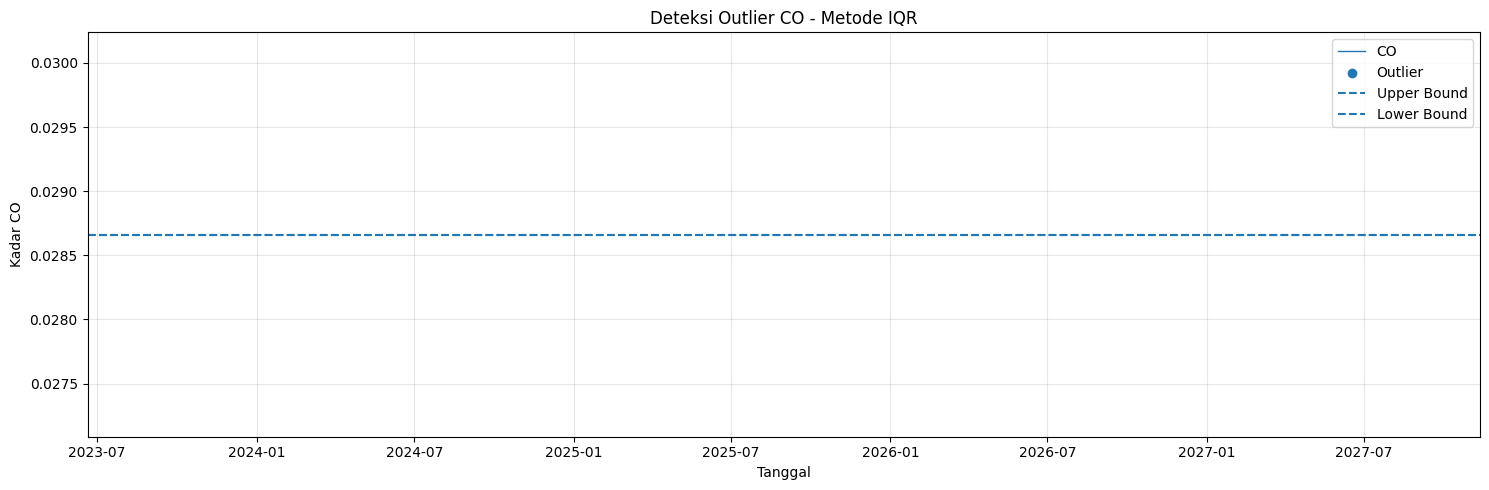

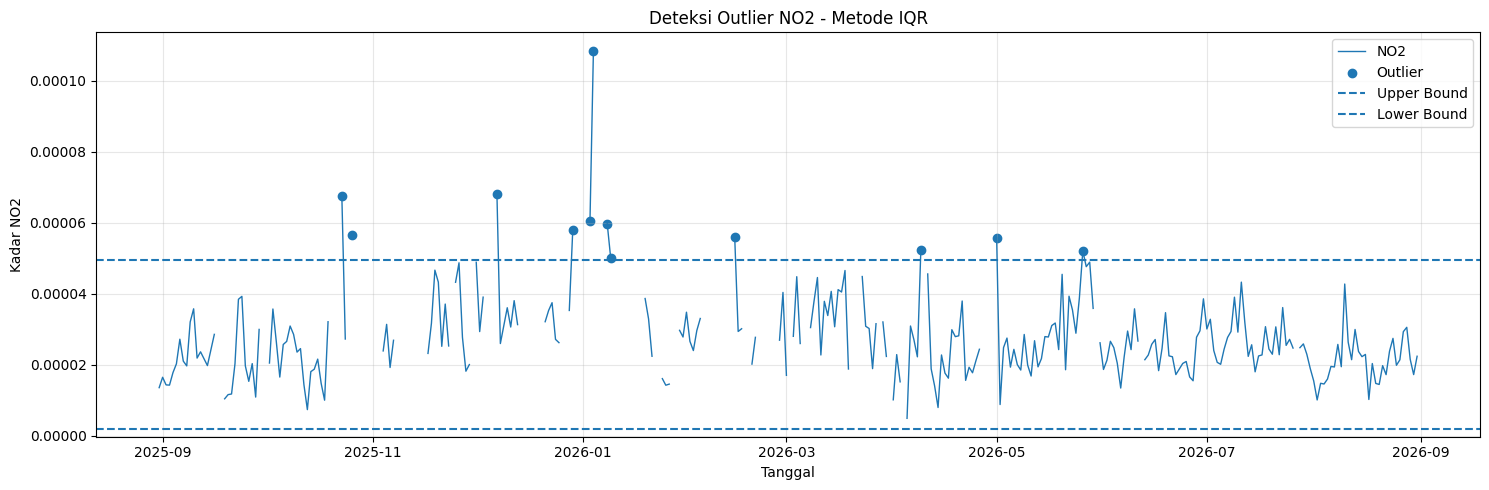

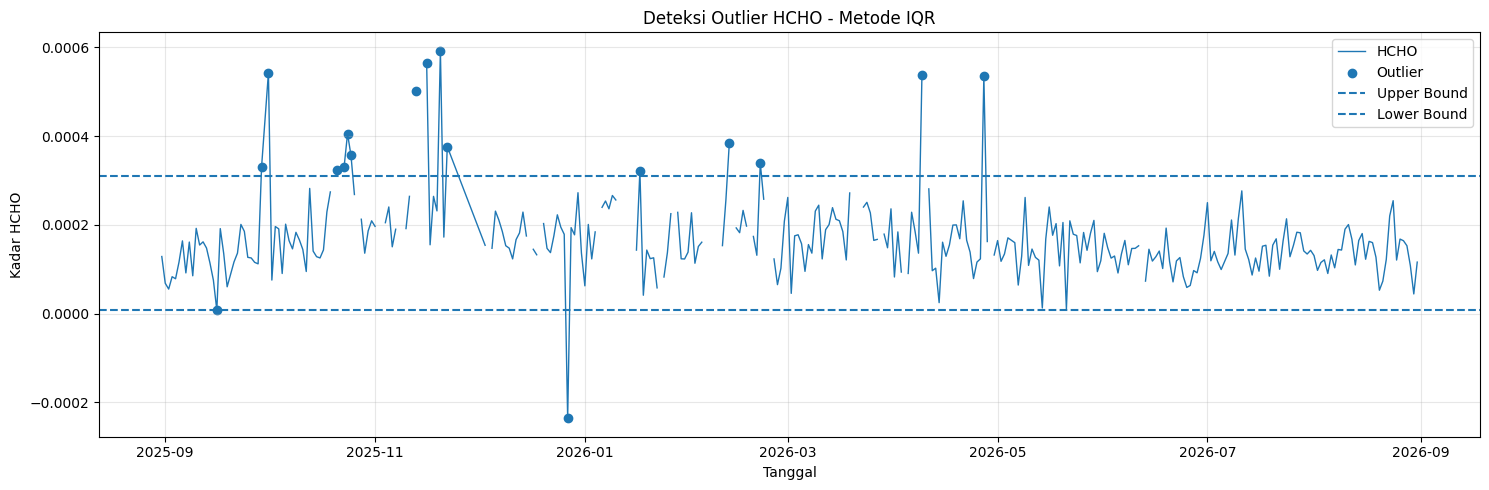

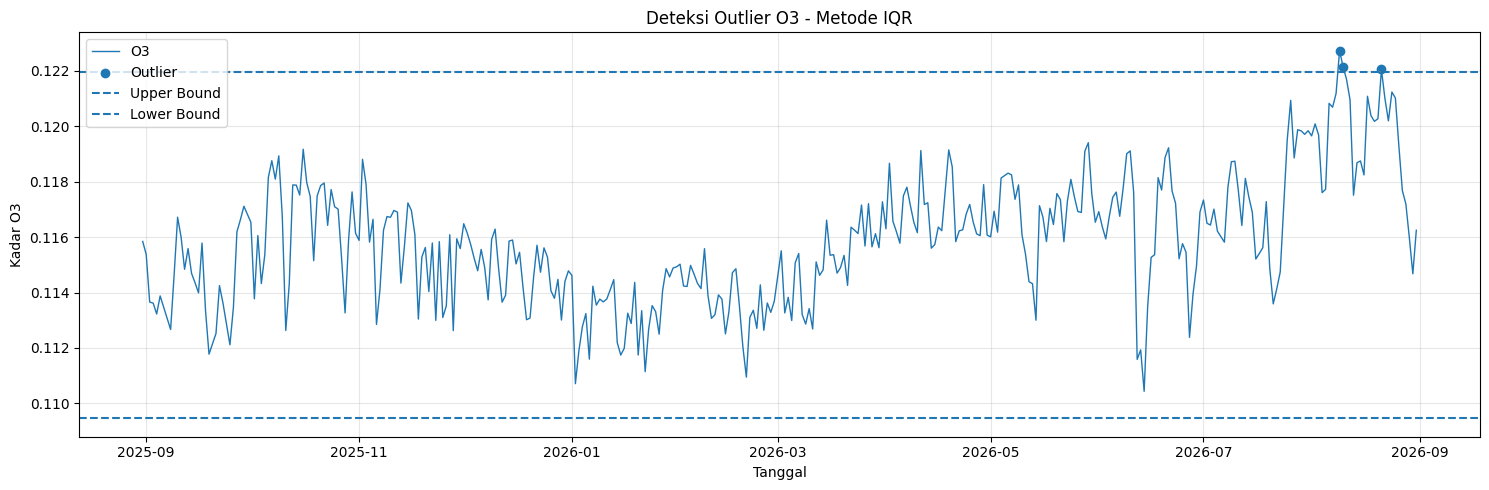

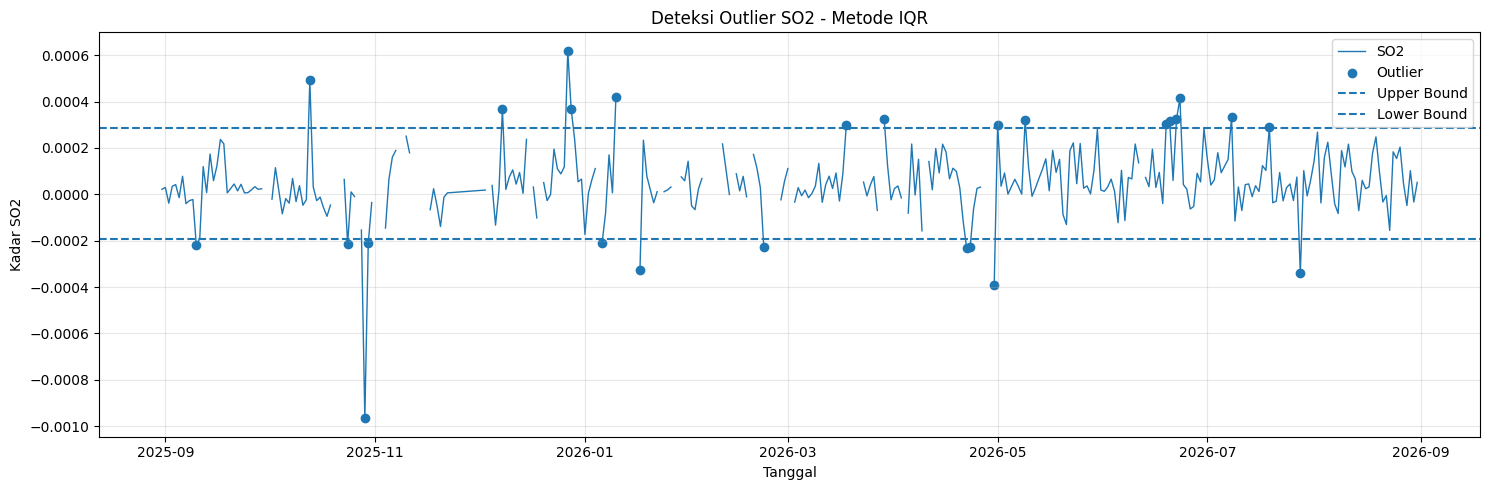

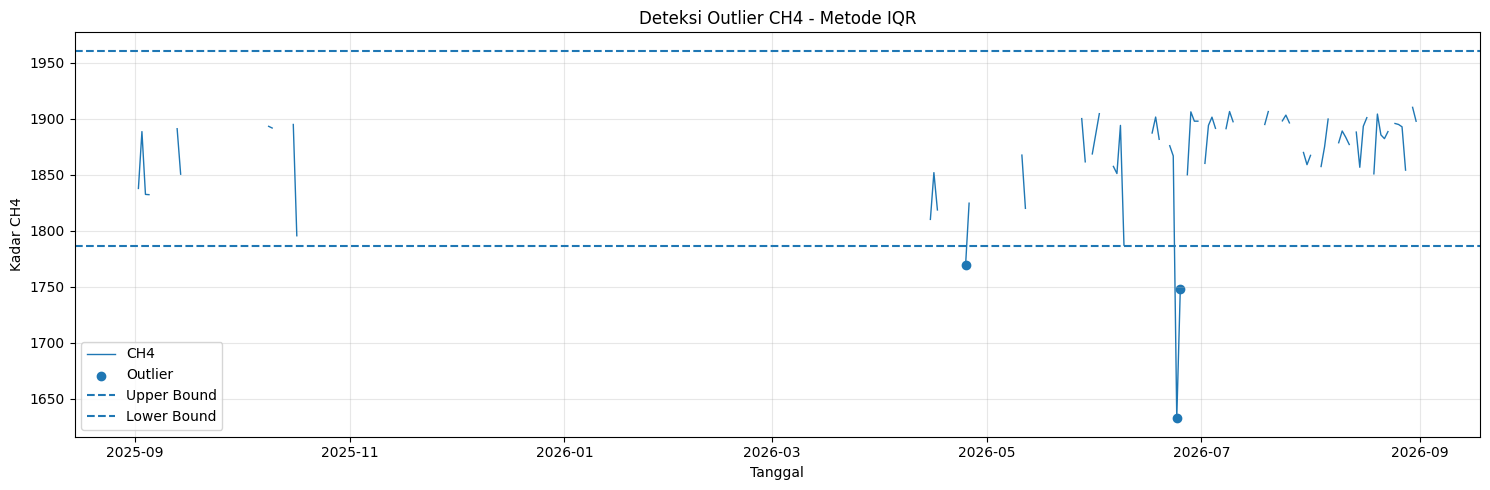

In [88]:
def plot_outliers(
    df,
    outliers,
    variable_name,
    lower_bound,
    upper_bound
):

    plt.figure(figsize=(15, 5))

    plt.plot(
        df["date"],
        df[variable_name],
        linewidth=1,
        label=variable_name
    )

    plt.scatter(
        outliers["date"],
        outliers[variable_name],
        marker="o",
        label="Outlier"
    )

    plt.axhline(
        upper_bound,
        linestyle="dashed",
        label="Upper Bound"
    )

    plt.axhline(
        lower_bound,
        linestyle="dashed",
        label="Lower Bound"
    )

    plt.title(
        f"Deteksi Outlier {variable_name} - Metode IQR"
    )

    plt.xlabel("Tanggal")
    plt.ylabel(
        f"Kadar {variable_name}"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_outliers(co_df, co_outliers, "CO", co_lower, co_upper)
plot_outliers(no2_df, no2_outliers, "NO2", no2_lower, no2_upper)
plot_outliers(hcho_df, hcho_outliers, "HCHO", hcho_lower, hcho_upper)
plot_outliers(o3_df, o3_outliers, "O3", o3_lower, o3_upper)
plot_outliers(so2_df, so2_outliers, "SO2", so2_lower, so2_upper)
plot_outliers(ch4_df, ch4_outliers, "CH4", ch4_lower, ch4_upper)

## 8. Tabel Ringkasan Data

Tabel ringkasan digunakan untuk membandingkan karakteristik seluruh polutan yang dianalisis di Kabupaten Bangkalan.

Informasi yang ditampilkan meliputi jumlah data, missing value, nilai minimum, maksimum, rata-rata, median, dan jumlah outlier.

Tabel ini membantu memberikan gambaran umum mengenai kondisi dataset sebelum dilakukan interpretasi lebih lanjut.


In [89]:
summary = []

for file_path, variable in [
    ("CO_timeseries.csv", "CO"),
    ("NO2_timeseries.csv", "NO2"),
    ("HCHO_timeseries.csv", "HCHO"),
    ("O3_timeseries.csv", "O3"),
    ("SO2_timeseries.csv", "SO2"),
    ("CH4_timeseries.csv", "CH4")
]:

    df = pd.read_csv(file_path)

    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        (df[variable] < lower) |
        (df[variable] > upper)
    ).sum()

    summary.append({
        "Polutan": variable,
        "Jumlah Data": len(df),
        "Missing Value": df[variable].isna().sum(),
        "Minimum": df[variable].min(),
        "Maximum": df[variable].max(),
        "Mean": df[variable].mean(),
        "Median": df[variable].median(),
        "Outlier": outlier_count
    })

summary_df = pd.DataFrame(summary)

summary_df

,Polutan,Jumlah Data,Missing Value,Minimum,Maximum,Mean,Median,Outlier
0,CO,1,0,0.028662,0.028662,0.028662,0.028662,0
1,NO2,364,80,0.000005,0.000109,0.000027,0.000026,12
2,HCHO,352,35,-0.000236,0.000593,0.000167,0.000153,17
3,O3,362,0,0.110438,0.122721,0.115848,0.115825,3
4,SO2,352,44,-0.000966,0.000619,0.000049,0.000036,26
5,CH4,216,132,1632.623400,1931.454600,1867.266076,1881.922300,3


## 9. Memasukkan data ke aiven

In [101]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from getpass import getpass

# =========================
# 1. Baca CSV
# =========================
df_baru = pd.read_csv("Data_Polutan_Bangkalan_Gabungan.csv")

print("Jumlah data CSV:", len(df_baru))
display(df_baru.head())


# =========================
# 2. Ubah nama kolom menjadi huruf kecil
# =========================
df_baru.columns = df_baru.columns.str.lower()

print("Nama kolom:")
print(df_baru.columns.tolist())


# =========================
# 3. Koneksi ke Aiven
# =========================
url = URL.create(
    drivername="postgresql+psycopg2",
    username="isi AIVEN_USER",
    password="isi AIVEN_PASSWORD",
    host="isi AIVEN_HOST",
    port="isi AIVEN_PORT",
    database="isi AIVEN_DB",
    query={"sslmode": "require"}
)
engine = create_engine(url)

# Tes koneksi
with engine.connect():
    print("Berhasil terhubung ke Aiven!")


# =========================
# 4. Masukkan data ke Aiven
# =========================
df_baru.to_sql(
    "data_polutan",
    engine,
    if_exists="append",
    index=False
)

print("Data berhasil dimasukkan ke Aiven!")


# =========================
# 5. Baca data dari Aiven
# =========================
df_cek = pd.read_sql(
    "SELECT * FROM data_polutan ORDER BY date",
    engine
)

print("Jumlah data di Aiven:", len(df_cek))

display(df_cek)

Jumlah data CSV: 366


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.028662,0.000014,0.000129,0.115841,0.000021,NaN
1,2025-09-01,NaN,0.000016,0.000069,0.115376,0.000029,NaN
2,2025-09-02,NaN,0.000014,0.000055,0.113657,-0.000038,1837.7645
3,2025-09-03,NaN,0.000014,0.000083,0.113616,0.000034,1888.4973
4,2025-09-04,NaN,0.000018,0.000079,0.113226,0.000042,1832.4469


Nama kolom:
['date', 'co', 'no2', 'hcho', 'o3', 'so2', 'ch4']
Berhasil terhubung ke Aiven!
Data berhasil dimasukkan ke Aiven!
Jumlah data di Aiven: 366


,id,date,co,no2,hcho,o3,so2,ch4
0,733,2025-08-31,0.028662,0.000014,0.000129,0.115841,0.000021,NaN
1,734,2025-09-01,NaN,0.000016,0.000069,0.115376,0.000029,NaN
2,735,2025-09-02,NaN,0.000014,0.000055,0.113657,-0.000038,1837.7645
3,736,2025-09-03,NaN,0.000014,0.000083,0.113616,0.000034,1888.4973
4,737,2025-09-04,NaN,0.000018,0.000079,0.113226,0.000042,1832.4469
...,...,...,...,...,...,...,...,...
361,1094,2026-08-27,NaN,0.000029,0.000164,0.117676,0.000048,1892.7664
362,1095,2026-08-28,NaN,0.000031,0.000153,0.117195,-0.000048,1854.1284
363,1096,2026-08-29,NaN,0.000022,0.000108,0.115979,0.000102,NaN
364,1097,2026-08-30,NaN,0.000017,0.000044,0.114675,-0.000033,1910.1371


# ANALISIS DATA TIME SERIES POLUTAN BANGKALAN MENGGUNAKAN POSTGRESQL AIVEN DAN KNIME

## 1. Pendahuluan

Data polutan merupakan data yang dapat digunakan untuk mengetahui kondisi dan perubahan kualitas udara pada suatu wilayah. Dalam tugas ini digunakan data polutan di daerah Bangkalan yang berbentuk time series, yaitu data yang dicatat berdasarkan waktu atau tanggal tertentu. Data yang digunakan terdiri dari beberapa jenis polutan, yaitu CO, NO2, HCHO, O3, SO2, dan CH4.

Pengolahan data dilakukan dengan memindahkan data dari file CSV ke PostgreSQL Aiven. Setelah data tersimpan di database, data tersebut kemudian ditarik ke KNIME Analytics Platform untuk dilakukan analisis statistik menggunakan Statistics Node. Analisis ini bertujuan untuk mengetahui karakteristik dari masing-masing fitur polutan berdasarkan nilai minimum, maksimum, rata-rata, median, standar deviasi, skewness, kurtosis, dan jumlah data yang kosong.

## 2. Tujuan

Tujuan dari kegiatan ini adalah:
1. Memindahkan data time series polutan dari CSV ke PostgreSQL Aiven.
2. Menghubungkan PostgreSQL Aiven dengan KNIME.
3. Menarik data polutan dari database ke KNIME.
4. Melakukan analisis statistik terhadap setiap fitur polutan.
5. Mengetahui karakteristik dan penyebaran data dari CO, NO2, HCHO, O3, SO2, dan CH4.
6. Menjelaskan rumus dan contoh perhitungan statistik yang digunakan.


## 3. Data yang Digunakan

Data yang digunakan merupakan data polutan daerah Bangkalan. Berdasarkan data yang telah diolah, terdapat 366 baris data dengan tujuh kolom utama, yaitu:
| Kolom | Keterangan         |
| ----- | ------------------ |
| date  | Tanggal pengamatan |
| CO    | Karbon monoksida   |
| NO2   | Nitrogen dioksida  |
| HCHO  | Formaldehida       |
| O3    | Ozon               |
| SO2   | Sulfur dioksida    |
| CH4   | Metana             |

Kolom date digunakan sebagai penanda waktu, sedangkan CO, NO2, HCHO, O3, SO2, dan CH4 digunakan sebagai fitur yang dianalisis.

## 4. Memindahkan Data ke PostgreSQL Aiven

Tahap pertama adalah membaca file CSV menggunakan Python. Data kemudian dimasukkan ke dalam database PostgreSQL yang dibuat menggunakan Aiven.

Kode yang digunakan untuk membaca data:

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from getpass import getpass

# =========================
# 1. Baca CSV
# =========================
df_baru = pd.read_csv("Data_Polutan_Bangkalan_Gabungan.csv")

print("Jumlah data CSV:", len(df_baru))
display(df_baru.head())


# =========================
# 2. Ubah nama kolom menjadi huruf kecil
# =========================
df_baru.columns = df_baru.columns.str.lower()

print("Nama kolom:")
print(df_baru.columns.tolist())


# =========================
# 3. Koneksi ke Aiven
# =========================
url = URL.create(
    drivername="postgresql+psycopg2",
    username="isi AIVEN_USER",
    password="isi AIVEN_PASSWORD",
    host="isi AIVEN_HOST",
    port="isi AIVEN_PORT",
    database="isi AIVEN_DB",
    query={"sslmode": "require"}
)
engine = create_engine(url)

# Tes koneksi
with engine.connect():
    print("Berhasil terhubung ke Aiven!")


# =========================
# 4. Masukkan data ke Aiven
# =========================
df_baru.to_sql(
    "data_polutan",
    engine,
    if_exists="append",
    index=False
)

print("Data berhasil dimasukkan ke Aiven!")


# =========================
# 5. Baca data dari Aiven
# =========================
df_cek = pd.read_sql(
    "SELECT * FROM data_polutan ORDER BY date",
    engine
)

print("Jumlah data di Aiven:", len(df_cek))

display(df_cek)

## 5. Menarik Data dari Aiven ke KNIME

Setelah data berhasil disimpan di Aiven, tahap selanjutnya adalah menghubungkan database tersebut dengan KNIME.

Workflow yang digunakan adalah:

PostgreSQL Connector --> DB Table Selector --> DB Reader --> Statistics

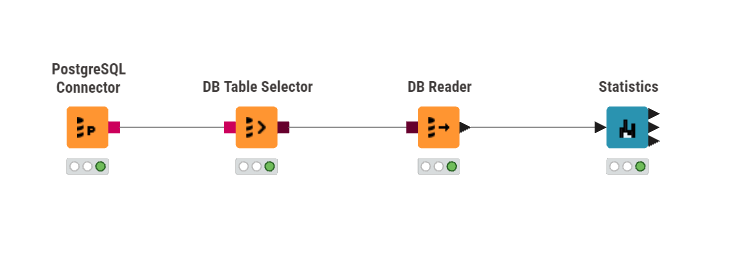

* PostgreSQL Connector

  Node PostgreSQL Connector digunakan untuk membuat koneksi antara KNIME dengan database PostgreSQL yang berada di Aiven. Pada tahap ini diperlukan informasi seperti host, port, database, username, dan password.

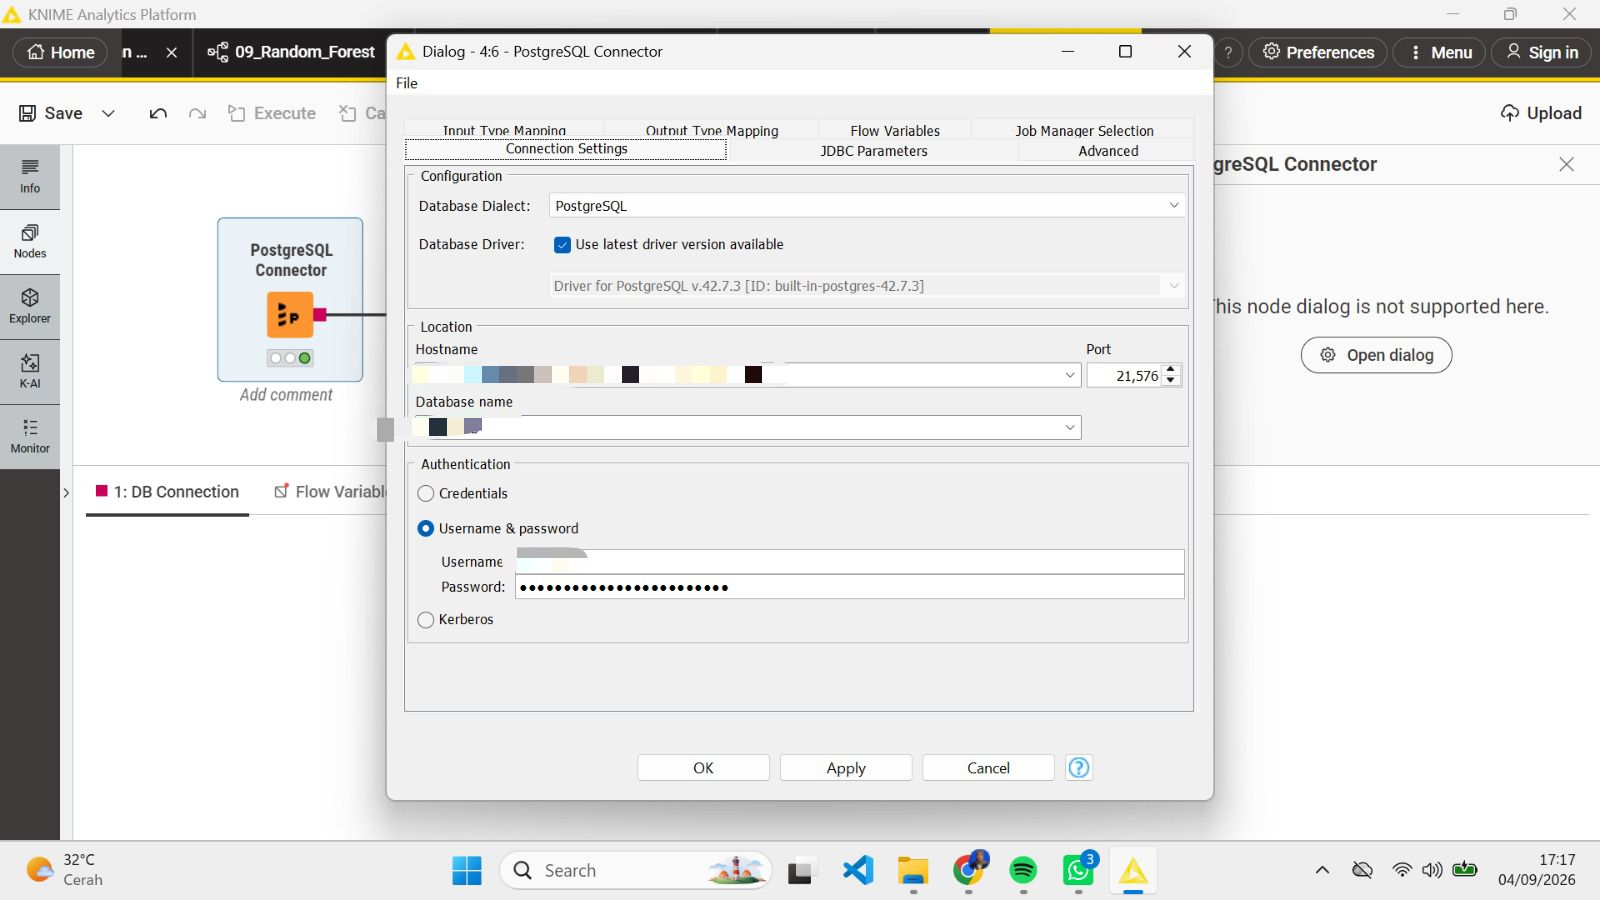

* DB Table Selector

Node DB Table Selector digunakan untuk menentukan tabel yang akan digunakan. Tabel yang dipilih adalah: data_polutan

Schema yang digunakan adalah: public

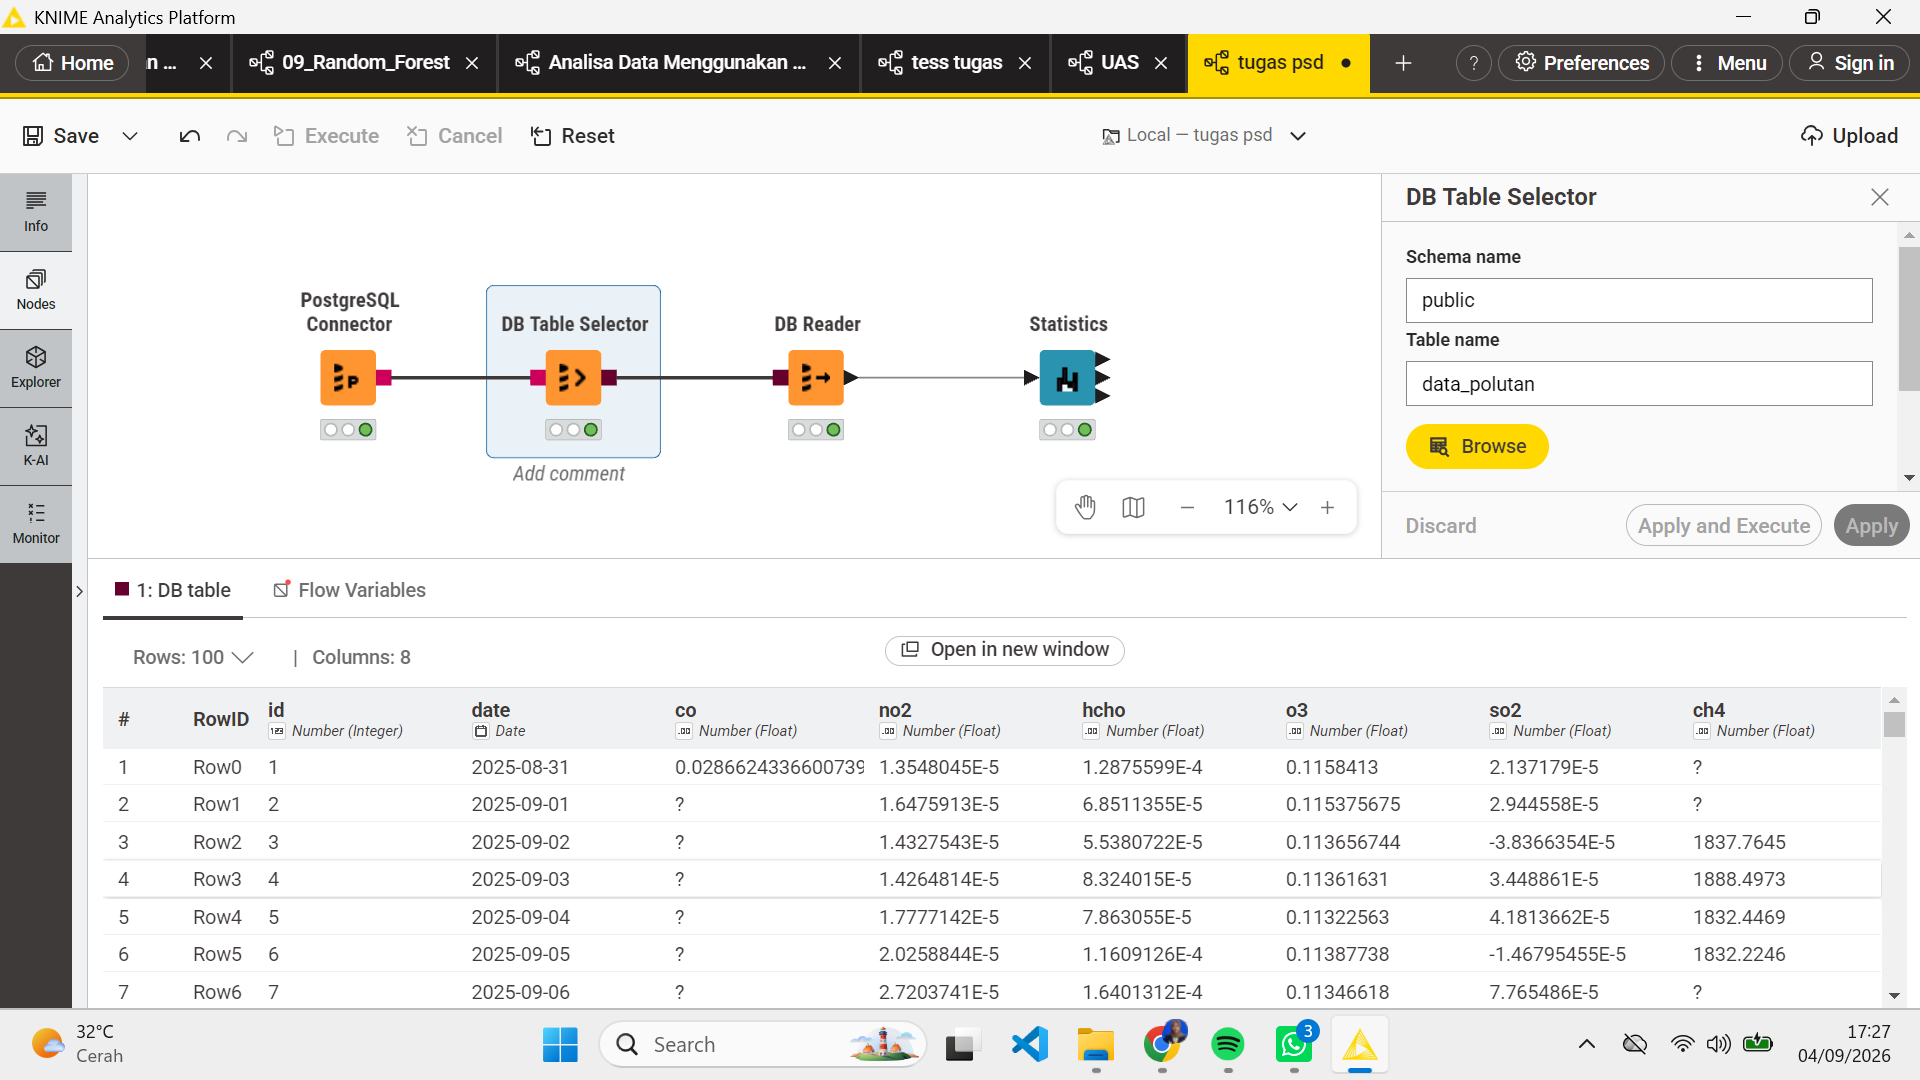

* DB Reader

Node DB Reader digunakan untuk mengambil data dari tabel PostgreSQL dan memasukkannya ke dalam workflow KNIME sebagai data table.

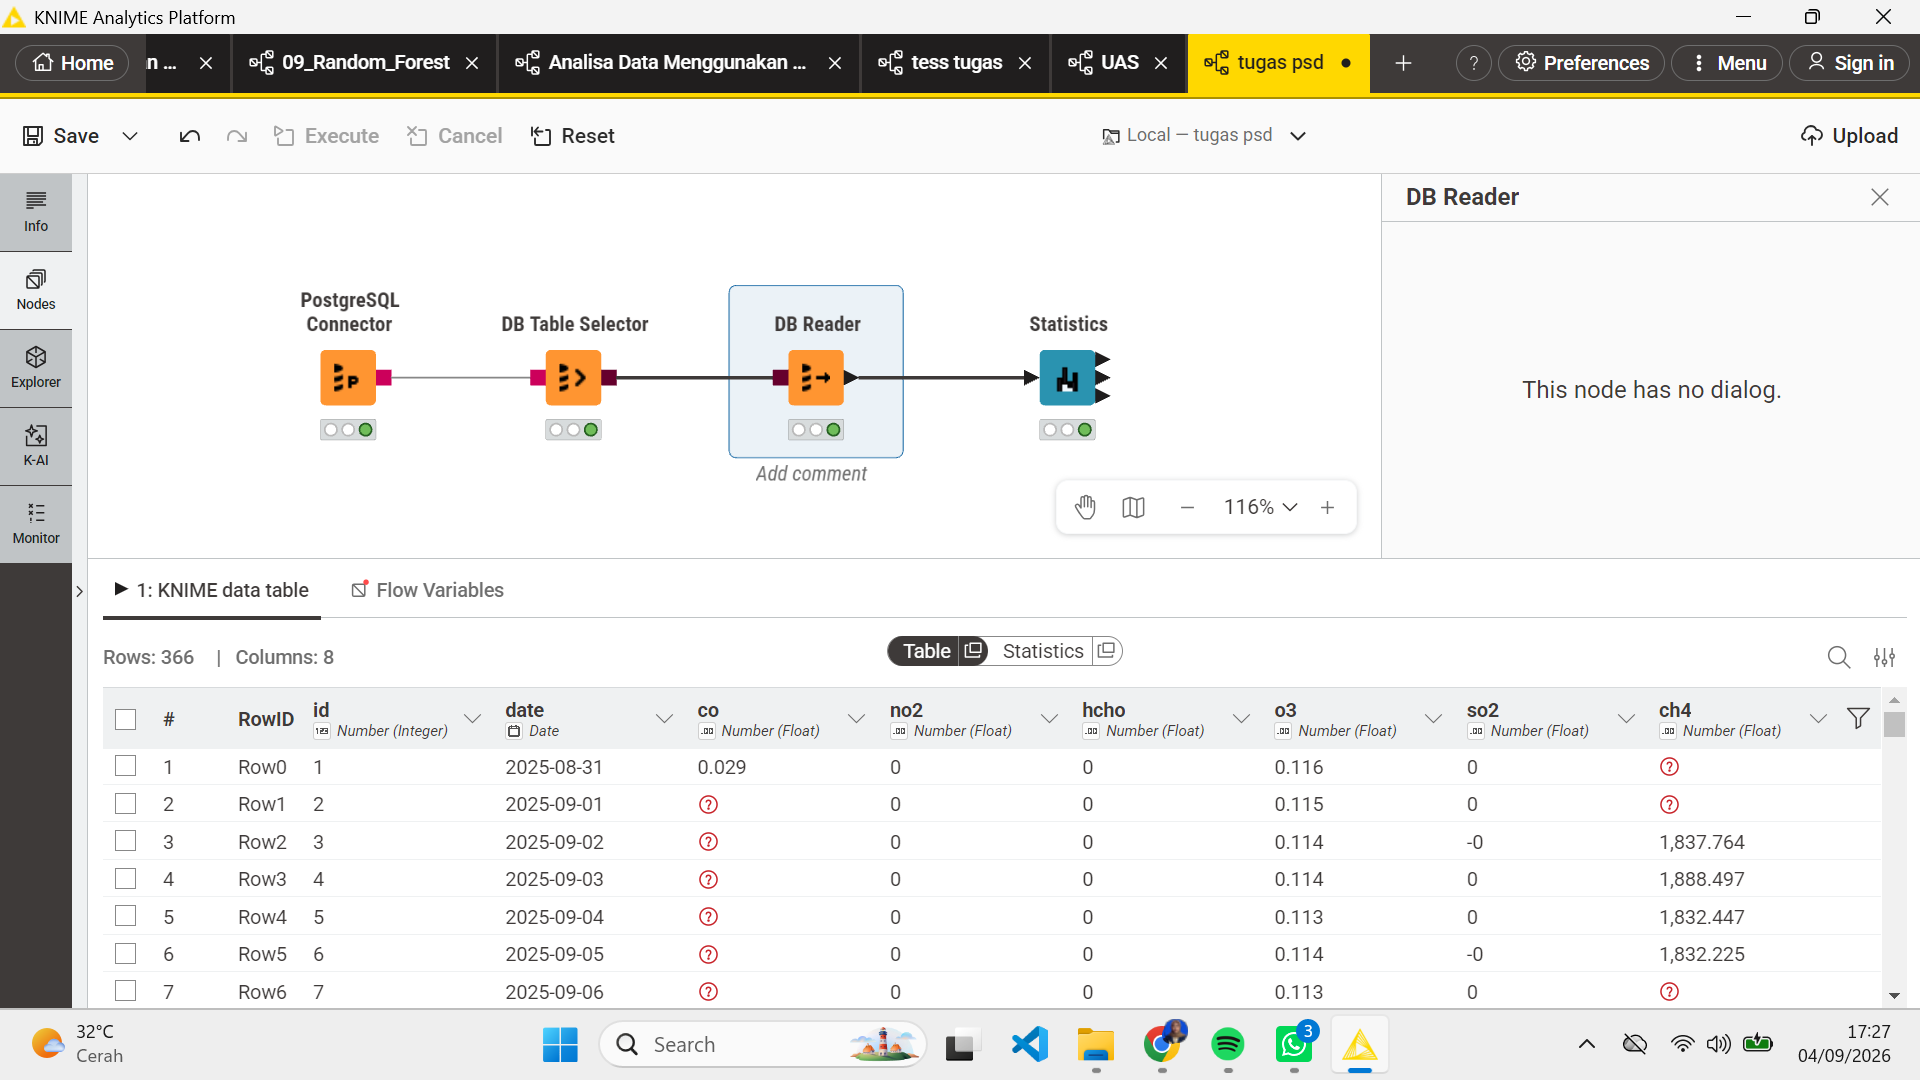

* Statistics

Setelah data berhasil dibaca, data diteruskan ke Statistics Node. Node ini digunakan untuk mengetahui ringkasan statistik dari setiap fitur numerik.

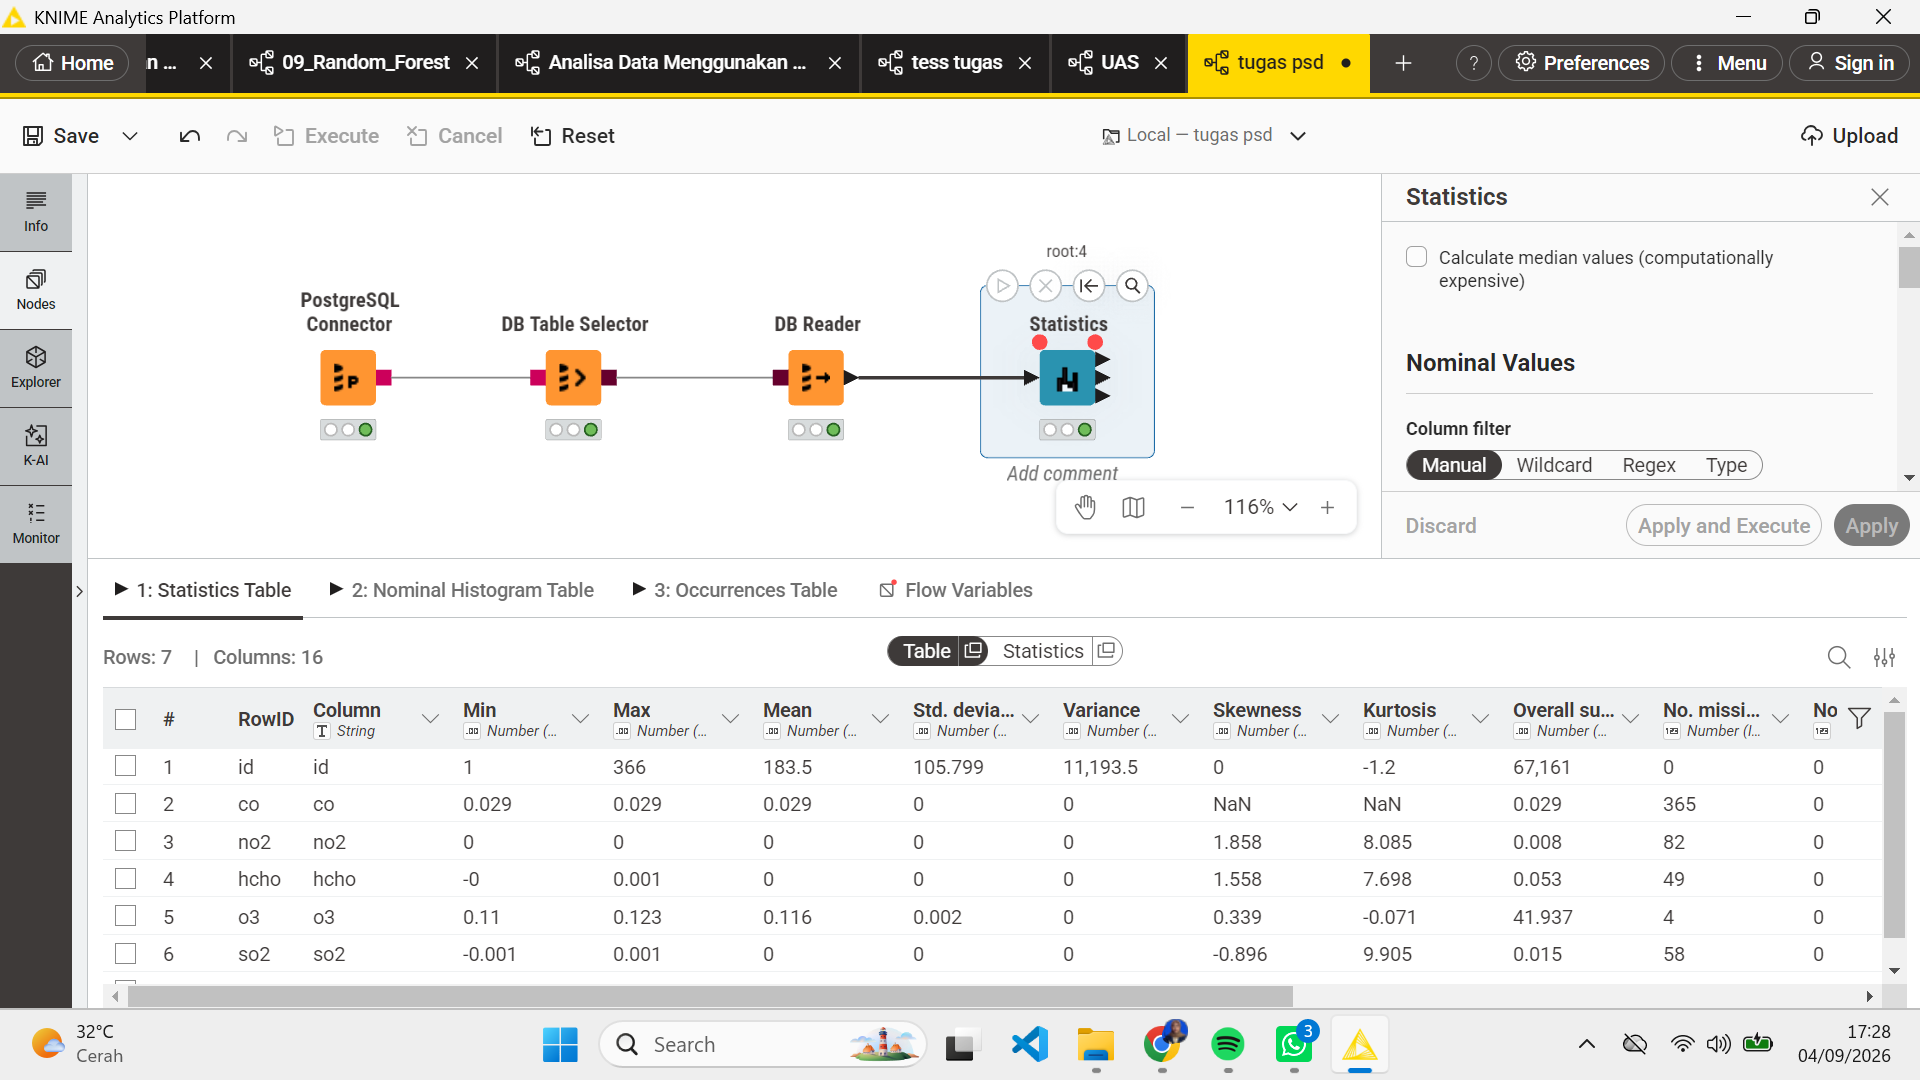

## 6. Analisis Statistik
Setelah data polutan berhasil ditarik dari PostgreSQL Aiven menggunakan PostgreSQL Connector, DB Table Selector, dan DB Reader, data kemudian dianalisis menggunakan Statistics Node pada KNIME. Analisis statistik digunakan untuk mengetahui karakteristik dari setiap fitur yang terdapat pada dataset.

Fitur yang dianalisis terdiri dari CO, NO2, HCHO, O3, SO2, dan CH4. Statistics Node menghasilkan beberapa ukuran statistik, yaitu minimum, maksimum, mean, standar deviasi, variance, skewness, kurtosis, overall sum, dan jumlah missing value.

### 6.1 Minimum (Min)

Minimum merupakan nilai paling rendah yang terdapat dalam suatu fitur.

Rumus:

$$ Min(X)=\min(x_1,x_2,...,x_n) $$

Contoh menggunakan data O3:

Lima data O3 pertama:

| Tanggal    |          O3 |
| ---------- | ----------: |
| 31/08/2025 |   0,1158413 |
| 01/09/2025 | 0,115375675 |
| 02/09/2025 | 0,113656744 |
| 03/09/2025 |  0,11361631 |
| 04/09/2025 |  0,11322563 |

Nilai paling kecil adalah:

$$ Min(O3)=0,11322563 $$

Jadi, dari lima contoh data tersebut, nilai minimum O3 adalah 0,11322563.


### 6.2 Maximum (Max)

Maximum merupakan nilai paling tinggi yang terdapat dalam suatu fitur.

Rumus:

$$ Max(X)=\max(x_1,x_2,...,x_n) $$

Dari lima data O3 di atas, nilai terbesar adalah:

$$ Max(O3)=0,1158413 $$

Jadi, nilai maksimum dari lima contoh data O3 adalah 0,1158413.


### 6.3 Mean

Mean merupakan nilai rata-rata dari data.

Rumus:

$$ Mean=\frac{\sum x_i}{n} $$

Menggunakan lima data O3 pertama:

$$ Mean= \frac{ 0,1158413+ 0,115375675+ 0,113656744+ 0,11361631+ 0,11322563 }{5} $$ $$ Mean=\frac{0,571715659}{5} $$ $$ Mean=0,1143431318 $$

Jadi, rata-rata dari lima contoh data O3 adalah 0,1143431318.


### 6.4 Standard Deviation

Standard deviation atau standar deviasi digunakan untuk mengetahui seberapa jauh nilai data menyebar dari rata-ratanya.

Rumus:

$$ s=\sqrt{\frac{\sum(x_i-\bar{x})^2}{n-1}} $$

Dari lima data O3 yang digunakan sebelumnya:

$$ \bar{x}=0,1143431318 $$

Setelah setiap nilai dikurangi mean, dikuadratkan, dijumlahkan, kemudian dibagi dengan \(n-1\) dan diakarkan, diperoleh:

$$ s\approx0,00117886 $$

Jadi, standar deviasi dari lima contoh data O3 adalah sekitar 0,00118.

Semakin kecil nilai standar deviasi, semakin dekat nilai-nilai data dengan rata-ratanya.


### 6.5 Variance

Variance atau varians merupakan ukuran penyebaran data yang diperoleh dari kuadrat standar deviasi.

Rumus:

$$ Variance=s^2 $$

Dari contoh O3:

$$ Variance=(0,00117886)^2 $$ $$ Variance\approx0,0000013897 $$

Jadi, variance dari lima contoh data O3 adalah sekitar 0,0000013897.


### 6.6 Skewness

Skewness digunakan untuk mengetahui apakah distribusi data cenderung simetris atau miring ke kanan/kiri.

Rumus:

$$ Skewness= \frac{1}{n} \sum \left(\frac{x_i-\bar{x}}{s}\right)^3 $$

Interpretasinya:

Skewness mendekati 0 → data relatif simetris.
Skewness positif → data cenderung menceng ke kanan.
Skewness negatif → data cenderung menceng ke kiri.

Contoh berdasarkan hasil Statistics Node kamu:

NO2:

$$ Skewness=1,858 $$

Karena nilainya positif, maka distribusi NO2 cenderung menceng ke kanan.

SO2:

$$ Skewness=-0,896 $$

Karena nilainya negatif, maka distribusi SO2 cenderung menceng ke kiri.


### 6.7 Kurtosis

Kurtosis digunakan untuk melihat bentuk distribusi data dan kecenderungan munculnya nilai yang jauh dari nilai pusat.

Rumus:

$$ Kurtosis= \frac{1}{n} \sum \left(\frac{x_i-\bar{x}}{s}\right)^4 $$

Berdasarkan hasil Statistics Node kamu:

| Fitur | Kurtosis |
| ----- | -------: |
| NO2   |    8,085 |
| HCHO  |    7,698 |
| O3    |   -0,071 |
| SO2   |    9,905 |


Contohnya pada SO2:

$$ Kurtosis=9,905 $$

Nilai tersebut cukup tinggi sehingga menunjukkan bahwa distribusi SO2 memiliki ekor yang relatif berat dan terdapat kemungkinan nilai yang cukup jauh dari sebagian besar data.


### 6.8 Overall Sum

Overall Sum merupakan jumlah seluruh nilai yang terdapat pada suatu fitur.

Rumus:

$$ Sum=\sum_{i=1}^{n}x_i $$

Menggunakan lima data O3 pertama:

$$ Sum=0,1158413+0,115375675+0,113656744+0,11361631+0,11322563 $$ $$ Sum=0,571715659 $$

Jadi, jumlah lima data O3 tersebut adalah 0,571715659.


### 6.9 No. Missing Values

No. Missing Values menunjukkan jumlah data yang kosong atau tidak memiliki nilai.

Rumus:

$$ Missing\ Value=Jumlah\ Data-Jumlah\ Data\ Terisi $$

Contoh berdasarkan hasil Statistics Node kamu:

CO = 365 missing value
NO2 = 82 missing value
HCHO = 49 missing value
O3 = 4 missing value
SO2 = 58 missing value

Contohnya pada O3:

$$ Missing\ Value=4 $$

Artinya terdapat 4 data O3 yang tidak memiliki nilai.

### 6.10 No. NaNs

No. NaNs menunjukkan jumlah nilai NaN (Not a Number) yang terdapat pada suatu kolom. NaN berbeda dengan data kosong biasa karena NaN merupakan nilai yang dianggap bukan angka.

Rumus:

$$ No.\ NaNs = Jumlah\ nilai\ NaN $$

Berdasarkan hasil Statistics Node pada data kamu, kolom No. NaNs menunjukkan nilai 0 pada fitur-fitur yang terlihat.

Artinya, tidak terdapat nilai yang secara khusus terdeteksi sebagai NaN. Data yang kosong pada dataset kamu lebih banyak tercatat sebagai Missing Values, bukan NaN.

Contoh:

Jika suatu kolom mempunyai 366 baris dan terdapat 10 nilai NaN, maka:

$$ No.\ NaNs=10 $$

Sedangkan pada hasil KNIME:

$$ No.\ NaNs=0 $$

yang berarti tidak ada nilai NaN.


### 6.11 No. +∞s

No. +∞s menunjukkan jumlah data yang memiliki nilai positif tak hingga (+∞).

Nilai +∞ biasanya muncul ketika suatu proses perhitungan menghasilkan nilai yang sangat besar atau terjadi pembagian dengan nol.

Rumus:

$$ No.\ +\infty s = Jumlah\ nilai\ (+\infty) $$

Berdasarkan hasil Statistics Node kamu, nilai No. +∞s = 0.

Artinya, tidak terdapat nilai positif tak hingga dalam data polutan.

Contoh:

Jika dari 366 data terdapat 3 nilai +∞:

$$ No.\ +\infty s=3 $$

Sedangkan pada data:

$$ No.\ +\infty s=0 $$

Jadi seluruh data tidak memiliki nilai positif tak hingga.


### 6.12 No. −∞s

No. −∞s menunjukkan jumlah data yang memiliki nilai negatif tak hingga (−∞).

Rumus:

$$ No.\ -\infty s = Jumlah\ nilai\ (-\infty) $$

Berdasarkan hasil Statistics Node kamu, nilai No. −∞s = 0.

Artinya, tidak ditemukan nilai negatif tak hingga pada data polutan.

Contoh:

Jika terdapat 2 nilai −∞ dari 366 data:

$$ No.\ -\infty s=2 $$

Sedangkan pada data:

No. −∞s=0


### 6.13 Median

Median merupakan nilai tengah setelah seluruh data diurutkan dari nilai terkecil sampai terbesar.

Median berbeda dengan mean karena median tidak menghitung jumlah seluruh nilai, tetapi mencari posisi tengah data.

Jika jumlah data ganjil

Rumus:

$$ Median=X_{\frac{n+1}{2}} $$
Jika jumlah data genap

Rumus:

$$ Median=\frac{X_{\frac{n}{2}}+X_{\frac{n}{2}+1}}{2} $$

Pada data kamu terdapat 366 baris, sehingga jumlah datanya genap.

Maka posisi median adalah data ke:

$$ \frac{366}{2}=183 $$

dan:

$$ 183+1=184 $$

Sehingga:

$$ Median=\frac{X_{183}+X_{184}}{2} $$

Artinya, KNIME mengambil nilai ke-183 dan ke-184 setelah data diurutkan, kemudian menghitung rata-ratanya.


### 6.14 Row Count

Row Count menunjukkan jumlah seluruh baris data yang masuk ke Statistics Node.

Berdasarkan screenshot KNIME kamu:

$$ Row\ Count=366 $$

Artinya, terdapat 366 baris data yang dianalisis oleh Statistics Node.

Jadi, meskipun beberapa fitur memiliki missing value, jumlah keseluruhan baris tetap 366.

Contohnya pada CO:

Row Count = 366
Missing Values = 365

Berarti dari 366 baris hanya terdapat:

$$ 366-365=1 $$

data CO yang memiliki nilai.

### 6.15 Histogram

Histogram merupakan grafik yang menunjukkan penyebaran atau distribusi nilai pada setiap fitur.

Histogram membagi nilai data ke dalam beberapa kelompok atau interval (bin), kemudian menunjukkan berapa banyak data yang berada pada setiap interval tersebut.

Konsep perhitungannya:

$$ Frekuensi = Jumlah\ data\ dalam\ suatu\ interval $$

Sebagai contoh, jika nilai O3 dikelompokkan menjadi beberapa interval:

| Interval O3 | Jumlah Data |
| ----------- | ----------: |
| 0,110–0,112 |          20 |
| 0,112–0,114 |          80 |
| 0,114–0,116 |         150 |
| 0,116–0,118 |          90 |
| 0,118–0,123 |          22 |

Maka histogram akan menunjukkan interval mana yang memiliki jumlah data paling banyak.

## 7. Kesimpulan

Berdasarkan proses yang telah dilakukan, data time series polutan Bangkalan berhasil dipindahkan dari CSV ke PostgreSQL Aiven dan kemudian berhasil ditarik ke KNIME menggunakan PostgreSQL Connector, DB Table Selector, dan DB Reader. Selanjutnya, data dianalisis menggunakan Statistics Node untuk mengetahui karakteristik setiap fitur polutan. Analisis meliputi nilai minimum, maksimum, mean, standar deviasi, variance, skewness, kurtosis, overall sum, missing values, NaN, nilai tak hingga, median, row count, dan histogram. Hasil statistik menunjukkan bahwa setiap polutan memiliki karakteristik data yang berbeda serta terdapat beberapa missing value pada beberapa fitur.